# **Istanbul Rental Market & Walkability Analysis**
# Project P1: Problem & EDA

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

# 1. Problem Statement

**Real-World Problem**

Finding affordable and well-located housing in Istanbul has become a significant challenge due to high inflation and a complex rental market. For students and young professionals, the difficulty isn't just the price; it is finding a home that balances affordability with urban accessibility (walkability). Traditional real estate listings focus on size and age, but they often ignore the "hidden value" of being near transport hubs, universities, and social amenities.

---

**Why It Matters & Who Benefits**

This project matters because it transforms subjective "neighborhood feelings" into objective data.
* Students: Benefit by identifying "Sweet Spots"—districts that offer high accessibility at lower-than-average costs.
* Young Professionals: Benefit by understanding the "price premium" of walkability, helping them make informed financial decisions.
* Urban Analysts: Can use this model to see how infrastructure (like new metro lines) impacts local rental values.

---

**Prediction Target**

The primary variable this project aims to predict is **price** (The monthly rental fee of an apartment in Turkish Lira - TL).

---

**Task Type: Regression**

Because our target variable (price) is a continuous numerical value. We are not trying to put houses into categories (like "expensive" or "cheap"); we are trying to predict an exact monetary value based on features like area, room count, and our custom walkability score.

---

**Our Goal & Roadmap**

* Data Engineering: Transform raw, web-scraped real estate data into a structured, machine-learning-ready format.
* Feature Engineering: Develop a custom "Walkability Score" (integrating transport, university density, and social hubs) and a "Student Suitability Index."
* Correlation Analysis: Quantify the mathematical relationship between urban accessibility and rental pricing.
* Decision Support: Identify the most cost-effective districts optimized for student life in Istanbul.

# 2. Dataset Description

**Feature Descriptions**

| Feature Name | Data Type | Description |
| :--- | :--- | :--- |
| **`price`** | Float | The cleaned monthly rent price in Turkish Lira (TL). |
| **`area_m2`** | Float | The gross internal area of the property in square meters. |
| **`room_count`** | Object | The raw room configuration string (e.g., "2+1", "1+0"). |
| **`district`** | Object | The standardized administrative district (İlçe) in Istanbul. |
| **`sub_district`** | Object | The smaller area inside the district (Semt), used for downstream geocoding in P2. |
| **`neighborhood`** | Object | The standardized neighborhood (Mahalle) of the property. |

---

| Engineered Feature | Data Type | Description |
| :--- | :--- | :--- |
| **`total_rooms`** | Float | Numerical sum of rooms and living areas derived from `room_count` (e.g., "2+1" → 3.0). |
| **`walkability_score`** | Float | District-level index (0–100) combining transit access (50%), university density (30%), and social amenities (20%). |
| **`price_per_room`** | Float | Per-tenant rent burden (price ÷ effective_rooms). Studio units treated as 1.5 rooms to reflect realistic single-occupant context. |
| **`student_score`** | Float | Composite index = 0.5 × walkability + 0.5 × affordability_percentile, capturing the cost–access trade-off for student housing. |


**Source & Data Acquisition**

The dataset consists of rental property listings in Istanbul, scraped from Sahibinden.com — Turkey's leading classifieds platform. Scraping was performed across all 39 official districts using URL-based district filters, which preserves district accuracy at the source level. The collection captures a snapshot of the Istanbul rental market and reflects active listing behavior at the time of acquisition.

---

**Raw Dataset Statistics**

* **Rows:** 16,221 (after initial DataFrame load and basic deduplication of identical scrapes)
* **Columns:** 6 (primary features before engineering: `price`, `area_m2`, `room_count`, `district`, `sub_district`, `neighborhood`)

---

**Known Limitations & Biases**

* **Missing Values:** The `neighborhood` column has 1,332 missing entries (~8.2%); all other primary columns are fully populated in the raw scrape.
* **Geographic Bias:** Single-platform sourcing favors districts with higher digital turnover. Esenyurt (980 listings), Şişli (843), Pendik (815), Ümraniye (792), and Kağıthane (785) are over-represented in the top 20.
* **Sub-district Granularity:** `sub_district` (semt-level) is preserved alongside `district` because P2 requires neighbourhood-resolution geocoding for the refined walkability metric.
* **Temporal Snapshot:** Single point-in-time data; seasonal effects (e.g., September university intake spikes) are not captured.
* **No Quality Variables:** Building age, floor level, and renovation status are not reliably scrapeable, leaving residual price variance unexplained at the structural level.


# 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import re
from sklearn.preprocessing import MinMaxScaler
from IPython.display import Image, display

# Gorsellestirmelerin notebook icinde gorunmesi icin
%matplotlib inline

# Ham veriyi yukle
df = pd.read_csv('../data/istanbul_emlak_data.csv')

# Web scraping'den gelen gereksiz filtre sutunlarini sil
df = df.drop(columns=['price_min_filter', 'price_max_filter'], errors='ignore')

# Tum satiri bos olan veya fiyati olmayan (reklam) satirlari sil
df = df.dropna(subset=['price'])

df.head()

,price,area_m2,room_count,district,sub_district,neighborhood
0,12.000 TL,75.0,1+1,arnavutkoy,Boğazköy,Atatürk Mh.
1,14.000 TL,80.0,2+1,arnavutkoy,Arnavutköy,Mustafa Kemal Paşa Mh.
2,13.000 TL,80.0,2+1,arnavutkoy,Haraççı,Karlıbayır Mh.
4,14.000 TL,75.0,1.5+1,arnavutkoy,Arnavutköy,Yunus Emre Mah.
5,13.000 TL,90.0,2+1,arnavutkoy,Arnavutköy,Yavuz Selim Mah.


In [2]:
#  GLOBAL VISUAL THEME —
#  Bu hucre tum notebook boyunca gecerli olacak renk/stil tanimlar

# Renk paleti
C_PRIMARY    = '#2E86AB'
C_SECONDARY  = '#E84855'
C_ACCENT     = '#F9A03F'
C_GREEN      = '#3BB273'
C_DARK       = '#1B1F3B'
C_LIGHT      = '#F7F9FC'

# Kategorik sıralı palet
CAT_PALETTE  = ['#2E86AB', '#E84855', '#F9A03F', '#3BB273',
                '#9B5DE5', '#F15BB5', '#00BBF9', '#00F5D4',
                '#FEE440', '#FB5607']

# Isı haritaları için
CMAP_DIV     = 'RdYlBu_r'   # Korelasyon heatmap
CMAP_SEQ     = 'Blues'       # Sıralı tek renkli
CMAP_MISSING = 'magma'       # Eksik veri heatmap

# Matplotlib rcParams
mpl.rcParams.update({

    'font.family'        : 'DejaVu Sans',
    'font.size'          : 11,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 12,
    'xtick.labelsize'    : 10,
    'ytick.labelsize'    : 10,
    'legend.fontsize'    : 10,
    'figure.titlesize'   : 16,
    'figure.titleweight' : 'bold',

    'figure.figsize'     : (12, 5),
    'figure.dpi'         : 110,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F7F9FC',
    'axes.edgecolor'     : '#CCCCCC',
    'axes.grid'          : True,
    'grid.color'         : '#DDDDDD',
    'grid.linestyle'     : '--',
    'grid.alpha'         : 0.6,

    'lines.linewidth'    : 2.0,
    'patch.edgecolor'    : 'white',

    'savefig.dpi'        : 150,
    'savefig.bbox'       : 'tight',
    'savefig.facecolor'  : 'white',
})

# Seaborn tema
sns.set_theme(
    style   = 'whitegrid',
    palette = CAT_PALETTE,
    rc      = {
        'axes.facecolor'  : '#F7F9FC',
        'figure.facecolor': 'white',
    }
)

In [3]:
# Display technical summary of the dataframe
print("\n--- Dataframe Information (.info()) ---")
df.info()

# Display statistical summary for numerical features
print("\n--- Statistical Summary (.describe()) ---")
display(df.describe())


--- Dataframe Information (.info()) ---
<class 'pandas.core.frame.DataFrame'>
Index: 16221 entries, 0 to 17631
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         16221 non-null  object 
 1   area_m2       16221 non-null  float64
 2   room_count    16221 non-null  object 
 3   district      16221 non-null  object 
 4   sub_district  16221 non-null  object 
 5   neighborhood  14889 non-null  object 
dtypes: float64(1), object(5)
memory usage: 887.1+ KB

--- Statistical Summary (.describe()) ---


,area_m2
count,16221.000000
mean,104.590962
std,41.761169
min,32.000000
25%,75.000000
50%,95.000000
75%,125.000000
max,450.000000


In [4]:
# Reporting the structure
print(f"Dataset Shape: {df.shape}")
print("\nData Types of Each Column:")
print(df.dtypes)

Dataset Shape: (16221, 6)

Data Types of Each Column:
price            object
area_m2         float64
room_count       object
district         object
sub_district     object
neighborhood     object
dtype: object


### _Stage1: Initial Data Inspection(Missing Values)_
First, we look at the raw data. The yellow lines in the Heatmap show where information is missing. We need to see how "dirty" our data is before cleaning.

This heatmap serves as the initial "Data Quality Audit." It visualizes the gaps in our raw dataset where information was not provided during the scraping process.

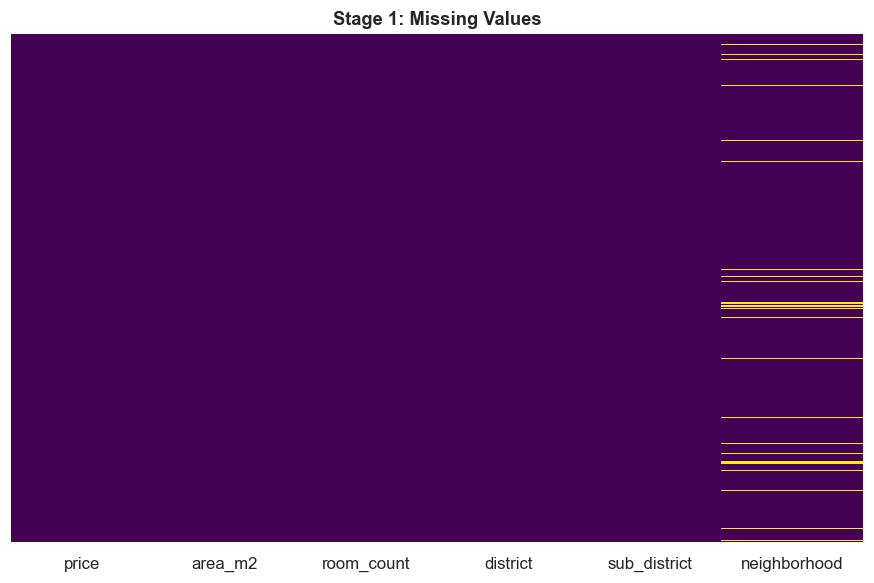

In [5]:
# Temizlik oncesi heat map
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 1: Missing Values")

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage1_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

_The yellow horizontal streaks in the `neighborhood` column represent the 1,332 listings (~8.2%) where the scraper could not capture mahalle-level granularity. All other primary columns (`price`, `area_m2`, `room_count`, `district`, `sub_district`) are fully populated in the raw scrape, so cleaning effort focuses on this single column plus type conversion and deduplication._

In [6]:
print("Eksik veri sayisi (Raw Data):")
print(df.isnull().sum())

Eksik veri sayisi (Raw Data):
price              0
area_m2            0
room_count         0
district           0
sub_district       0
neighborhood    1332
dtype: int64


_Missing values were detected with `.isnull().sum()`. Listings missing critical features — `price`, `area_m2`, `district`, or `total_rooms` — were dropped because these are either the target or core predictors and any imputation would introduce systematic noise into the regression model. Rows missing only `neighborhood` were retained because `district` and `sub_district` together still provide usable location resolution._

**Summary for Section 3**

* **Dataset Shape:** Raw dataset contains **16,221 rows × 6 columns**.
* **Column Types:** `price`, `room_count`, `district`, `sub_district`, `neighborhood` are `object` (string); `area_m2` is `float64`.
* **Missing Values:** 1,332 missing entries in `neighborhood` only.

---

**Critical Issues Identified:**

* `price` strings (e.g., `"15.000 TL"`) need conversion to numeric.
* `room_count` strings (e.g., `"2+1"`) need decomposition into a numeric `total_rooms` column.
* District/neighborhood names need ASCII normalisation and lowercase standardisation for consistent grouping.
* Duplicates need removal — the same listing can appear under multiple price-filter scrape passes.
* `.describe()` on raw data only reports `area_m2` because it is the sole numeric column at this stage.


# 4. Data Cleaning
Step 4.1: Fixing Incorrect Data Types & Category Standardization

+ Walkability Score
+ Stage2

Step 4.2: Outlier Analysis & Domain-Based Removal

+ Student Score
+ Stage3

### 4.1 Fixing Incorrect Data Types & Category Standardization 

The raw data contains string values with currency symbols, units, and inconsistent casing. Machine learning algorithms require clean numerical inputs and consistent categorical labels.

**Cleaning Operations Applied:**

* **Deduplication:** 775 duplicate rows removed.
* **Price parsing:** Strings like `"15.000 TL"` → `15000.0` (float).
* **Room decomposition:** `room_count` → `total_rooms` numeric (e.g., `"2+1"` → `3.0`, `"Stüdyo (1+0)"` → `1.0`).
* **Text standardisation:** `district`, `sub_district`, `neighborhood` lowercased and ASCII-normalised (`ğ`→`g`, `ı`→`i`, `ş`→`s`, etc.) for consistent grouping.
* **District validation:** Each row's `district` value is checked against the canonical list of 38 Istanbul districts. Because the scraper used URL-based district filters, no swap correction is needed — only normalisation.

**Sub-district preservation:** `sub_district` (e.g., "Bolluca", "Hadımköy") is kept because it offers finer-grained location resolution than `district` alone. P2 will use it as the input granularity for centroid-based geocoding.

In [7]:
# Duplicate satirlari kaldir
print(f"Duplicate: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Fiyati temizle: "25.000 TL" → 25000.0
def clean_price(price_str):
    if pd.isna(price_str): return np.nan
    if isinstance(price_str, (int, float)): return float(price_str)
    s = str(price_str).replace('TL', '').replace('tl', '').strip()
    price = re.sub(r'[^\d]', '', s)
    return float(price) if price else np.nan

# Metrekareyi temizle: "120 m2" → 120.0
def clean_m2(m2_str):
    if pd.isna(m2_str): return np.nan
    m2 = str(m2_str).replace('m2', '').replace(' ', '').strip()
    return float(m2) if m2 else np.nan

# Oda sayisini sayisalastir: "2+1" → 3.0, "Studyo" → 1.0
def simple_room_count(room_str):
    if pd.isna(room_str) or 'stüdyo' in str(room_str).lower():
        return 1.0
    try:
        return sum(float(p) for p in str(room_str).split('+'))
    except:
        return np.nan

df['price']       = df['price'].apply(clean_price)
df['area_m2']     = df['area_m2'].apply(clean_m2)
df['total_rooms'] = df['room_count'].apply(simple_room_count)

print(df[['price', 'area_m2', 'total_rooms']].describe().round(1))

Duplicate: 775
          price  area_m2  total_rooms
count   15446.0  15446.0      15444.0
mean    46856.2    104.9          3.1
std     26737.8     42.0          1.0
min     10000.0     32.0          1.0
25%     28562.5     75.0          2.0
50%     39500.0     95.0          3.0
75%     57000.0    125.0          4.0
max    150000.0    450.0          9.0


In [8]:
# Turkce karakterleri ASCII'ye donustur, kucuk harfe al
def simple_standardize(text):
    if pd.isna(text): return np.nan
    text = str(text).lower().strip()
    for tr, en in {'ç':'c','ğ':'g','ı':'i','ö':'o','ş':'s','ü':'u'}.items():
        text = text.replace(tr, en)
    return text

df['district']     = df['district'].apply(simple_standardize)
df['neighborhood'] = df['neighborhood'].apply(simple_standardize)
df['sub_district'] = df['sub_district'].apply(simple_standardize)

# Mahalle adinin sonundaki "mh / mah / mahallesi" eklerini kaldir
pattern = r'\s+(mh|mah|mahallesi)\.?$'
df['neighborhood'] = df['neighborhood'].str.replace(pattern, '', regex=True).str.strip()

# Bos stringleri NaN'a cevir
for col in ['district', 'sub_district', 'neighborhood']:
    df[col] = df[col].replace('', np.nan)

In [9]:
# 38 Istanbul ilcesi
# URL bazli arama yapildigi icin district sutunu zaten dogru — konum duzeltmesine gerek yok
official_districts = {
    'arnavutkoy', 'atasehir', 'avcilar', 'bagcilar', 'bahcelievler',
    'bakirkoy', 'basaksehir', 'bayrampasa', 'besiktas', 'beykoz', 'beylikduzu',
    'beyoglu', 'buyukcekmece', 'catalca', 'cekmekoy', 'esenler', 'esenyurt',
    'eyupsultan', 'fatih', 'gaziosmanpasa', 'gungoren', 'kadikoy', 'kagithane',
    'kartal', 'kucukcekmece', 'maltepe', 'pendik', 'sancaktepe', 'sariyer',
    'silivri', 'sultanbeyli', 'sultangazi', 'sile', 'sisli', 'tuzla',
    'umraniye', 'uskudar', 'zeytinburnu'
}

df = df[df['district'].isin(official_districts)]

# sub_district bos ise ilce adini kullan (geocoding fallback icin)
df['sub_district'] = df['sub_district'].fillna(df['district'])

# Neighborhood bos ise "merkez" isaretlenir
df['neighborhood'] = df['neighborhood'].fillna('merkez')

print(f"Benzersiz ilce: {df['district'].nunique()}")
print(f"Kalan ilan: {len(df)}")

Benzersiz ilce: 38
Kalan ilan: 15446


In [10]:
# Sutun ozeti
print("Sutun yapisi:")
print(df.dtypes)
print(f"\nEksik deger sayisi:")
print(df.isnull().sum())

Sutun yapisi:
price           float64
area_m2         float64
room_count       object
district         object
sub_district     object
neighborhood     object
total_rooms     float64
dtype: object

Eksik deger sayisi:
price           0
area_m2         0
room_count      0
district        0
sub_district    0
neighborhood    0
total_rooms     2
dtype: int64


In [11]:
df.to_csv('../data/istanbul_emlak_fixed.csv', index=False)

print("Veri 'istanbul_emlak_fixed.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_fixed.csv' adıyla kaydedildi.


### Walkability Score (Urban Accessibility — P1 District-Level Approximation)

The walkability score quantifies how accessible a property's surrounding area is to amenities students rely on most: public transport, university campuses, and daily-use social/commercial venues.

**P1 methodology — district-level aggregation:**
At this stage the score is computed once per district from publicly available aggregate counts (IBB transit station inventories, YÖK university campus listings, qualitative social/amenity indices). Every listing in a given district therefore receives the same walkability value. This is a **deliberately coarse approximation** designed to give early EDA a usable accessibility signal without geocoding.

**Component weights:**

| Component | Weight | Source |
| :--- | :--- | :--- |
| Transport (Metro / Metrobüs / Marmaray / Vapur stations) | 0.50 | IBB transit data |
| University campuses | 0.30 | YÖK registry |
| Social / amenity index | 0.20 | Qualitative composite |

$$\text{Walkability Score} = (\text{Transport} \times 0.5) + (\text{University} \times 0.3) + (\text{Social} \times 0.2)$$

The final score is rescaled to the 0–100 range.

> **P2 plan:** This district-level approximation will be replaced with neighbourhood-level geocoded features (Nominatim centroids + Overpass API POI counts within configurable radii) to capture intra-district variance that the current methodology cannot.

In [12]:
df = pd.read_csv('../data/istanbul_emlak_fixed.csv')
# Ham Istatistikler (IBB, YÖK ve Sosyal Endeks yaklaşık verileri)
# 1. stations: Metro, Metrobus, Marmaray, Vapur durak sayisi
# 2. univ_campuses: Ilce sinirlarindaki aktif yerleske/fakulte sayisi
# 3. social_points: Sosyal imkanlar (kafe, kutuphane, yesil alan) yogunluk puani (0-100)
raw_stats = {
    'besiktas':    {'stations': 12, 'univ_campuses': 10, 'social_points': 95},
    'kadikoy':     {'stations': 15, 'univ_campuses': 6,  'social_points': 98},
    'beyoglu':     {'stations': 14, 'univ_campuses': 5,  'social_points': 100},
    'sisli':       {'stations': 14, 'univ_campuses': 8,  'social_points': 90},
    'fatih':       {'stations': 18, 'univ_campuses': 12, 'social_points': 75},
    'uskudar':     {'stations': 10, 'univ_campuses': 5,  'social_points': 80},
    'sariyer':     {'stations': 8,  'univ_campuses': 9,  'social_points': 80},
    'atasehir':    {'stations': 8,  'univ_campuses': 4,  'social_points': 80},
    'bakirkoy':    {'stations': 9,  'univ_campuses': 4,  'social_points': 85},
    'zeytinburnu': {'stations': 12, 'univ_campuses': 4,  'social_points': 65},
    'umraniye':    {'stations': 10, 'univ_campuses': 2,  'social_points': 65},
    'eyupsultan':  {'stations': 9,  'univ_campuses': 3,  'social_points': 60},
    'kagithane':   {'stations': 7,  'univ_campuses': 3,  'social_points': 55},
    'kartal':      {'stations': 8,  'univ_campuses': 2,  'social_points': 60},
    'avcilar':     {'stations': 6,  'univ_campuses': 7,  'social_points': 50},
    'maltepe':     {'stations': 7,  'univ_campuses': 4,  'social_points': 65},
    'bagcilar':    {'stations': 12, 'univ_campuses': 3,  'social_points': 45},
    'esenyurt':    {'stations': 3,  'univ_campuses': 2,  'social_points': 35},
    'beylikduzu':  {'stations': 4,  'univ_campuses': 2,  'social_points': 45},
    'silivri':     {'stations': 1,  'univ_campuses': 1,  'social_points': 20},
     'pendik':        {'stations': 12, 'univ_campuses': 4, 'social_points': 60},
    'kucukcekmece':  {'stations': 9,  'univ_campuses': 4, 'social_points': 60},
    'bahcelievler':  {'stations': 8,  'univ_campuses': 2, 'social_points': 55},
    'basaksehir':    {'stations': 8,  'univ_campuses': 3, 'social_points': 55},
    'tuzla':         {'stations': 7,  'univ_campuses': 5, 'social_points': 55},
    'esenler':       {'stations': 6,  'univ_campuses': 2, 'social_points': 45},
    'gaziosmanpasa': {'stations': 5,  'univ_campuses': 1, 'social_points': 45},
    'sultangazi':    {'stations': 5,  'univ_campuses': 1, 'social_points': 35},
    'bayrampasa':    {'stations': 5,  'univ_campuses': 1, 'social_points': 50},
    'sancaktepe':    {'stations': 4,  'univ_campuses': 1, 'social_points': 35},
    'cekmekoy':      {'stations': 4,  'univ_campuses': 2, 'social_points': 40},
    'gungoren':      {'stations': 4,  'univ_campuses': 1, 'social_points': 50},
    'beykoz':        {'stations': 3,  'univ_campuses': 2, 'social_points': 55},
    'arnavutkoy':    {'stations': 3,  'univ_campuses': 1, 'social_points': 30},
    'sultanbeyli':   {'stations': 2,  'univ_campuses': 1, 'social_points': 30},
    'buyukcekmece':  {'stations': 2,  'univ_campuses': 2, 'social_points': 45},
    'sile':          {'stations': 1,  'univ_campuses': 1, 'social_points': 30},
    'catalca':       {'stations': 1,  'univ_campuses': 0, 'social_points': 20},
}

# Ham veriyi DataFrame'e cevir.
stats_df = pd.DataFrame.from_dict(raw_stats, orient='index')

# Normalizasyon (0-100): En yuksek sayiya sahip olan ilce 100 puan alacak sekilde
def normalize(column):
    return (column - column.min()) / (column.max() - column.min()) * 100

stats_df['transport_score'] = normalize(stats_df['stations'])
stats_df['univ_score'] = normalize(stats_df['univ_campuses'])
stats_df['social_score'] = normalize(stats_df['social_points'])

# Formülü Uygula: Transport (%50), University (%30), Social (%20)
stats_df['final_walkability_score'] = (
    (stats_df['transport_score'] * 0.5) +
    (stats_df['univ_score'] * 0.3) +
    (stats_df['social_score'] * 0.2)
).round(2)

# Veriye uygula.
# Gizli bosluklari temizleyerek eslesmeyi garanti altina aliyoruz.
df['district'] = df['district'].str.strip()
final_metrics_map = stats_df['final_walkability_score'].to_dict()
df['walkability_score'] = df['district'].map(final_metrics_map).fillna(10.0)

# Kontrol et.
print("Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):")
print(stats_df[['transport_score', 'univ_score', 'social_score', 'final_walkability_score']].sort_values(by='final_walkability_score', ascending=False))

Veriden Türetilmiş Skorlar (Normalizasyon Sonrası):
               transport_score  univ_score  social_score  \
fatih               100.000000  100.000000         68.75   
besiktas             64.705882   83.333333         93.75   
sisli                76.470588   66.666667         87.50   
kadikoy              82.352941   50.000000         97.50   
beyoglu              76.470588   41.666667        100.00   
sariyer              41.176471   75.000000         75.00   
uskudar              52.941176   41.666667         75.00   
zeytinburnu          64.705882   33.333333         56.25   
pendik               64.705882   33.333333         50.00   
bakirkoy             47.058824   33.333333         81.25   
bagcilar             64.705882   25.000000         31.25   
atasehir             41.176471   33.333333         75.00   
kucukcekmece         47.058824   33.333333         50.00   
umraniye             52.941176   16.666667         56.25   
eyupsultan           47.058824   25.000000      

### Saving the Scored Dataset
Now our data has a "Walkability Score." We save it as a new CSV file.

In [13]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_walkability.csv', index=False)

print("Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_walkability.csv' adıyla kaydedildi.


### _Stage 2: Outlier Analysis (Visual Identification)_
We check the data before removing outliers.
Some data is not realistic. For example, houses with 1500 $m^2$ area.
These "Outliers" break our graphs and models.
We see these spikes in the red histograms below.
This "noise" makes our graphs look bad.

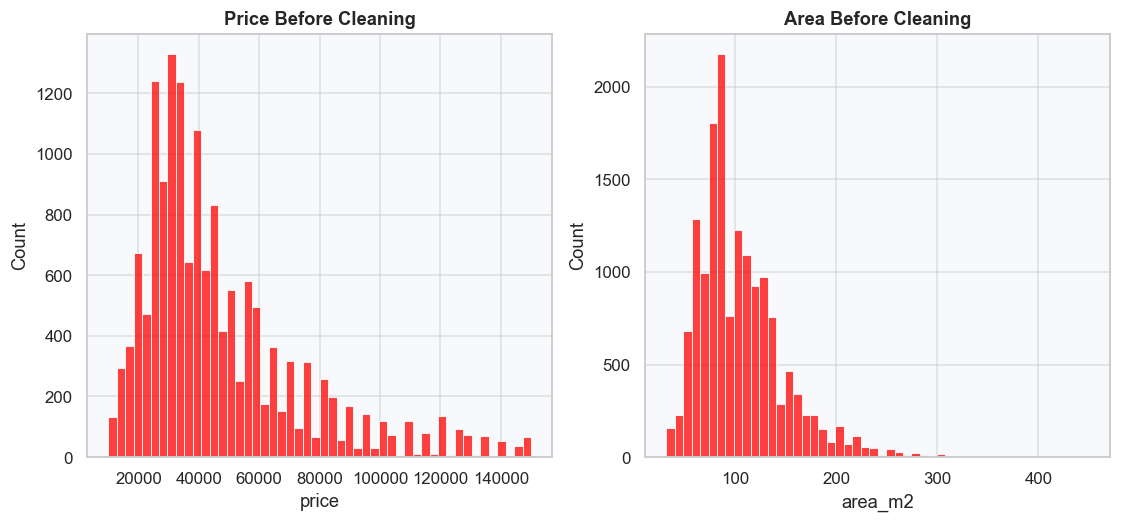

In [14]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Fiyat dagilimi (Kirmizi)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, color='red')
plt.title('Price Before Cleaning')

# Metrekare dagilimi (Kirmizi)
plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=50, color='red')
plt.title('Area Before Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage2_dirty_distribution.png', dpi=300)
plt.show()

_The extreme right-skewness and 'spikes' at near-zero or million-plus values represent unrealistic outliers (e.g., 1 TL rents or massive land plots) that would degrade the performance of any regression model._

### 4.2 Outlier Analysis & Domain-Based Removal

### Handling Missing Values and Outliers

**Method: Domain-Based Threshold Filtering**

To ensure data quality, both missing values and unrealistic observations are addressed using thresholds informed by Istanbul real estate domain knowledge rather than purely statistical IQR rules.

**Operations applied:**

* **Critical-column dropna:** Listings missing `price`, `area_m2`, `district`, or `total_rooms` are dropped — these cannot be imputed without bias.
* **Price range:** The raw scrape was already constrained to 10,000–150,000 TL via URL filters, so extreme luxury and fake daily rentals are excluded at source.
* **Area filtering:** Restricted to 30–250 m². This removes scraping artefacts (single rooms, rooftop terraces listed as full units) and extreme outliers (commercial plots, multi-floor villas) that distort the scale.
* **Room cap:** Listings with `total_rooms > 6` removed (e.g., 7+1, 4+3 configurations) — these are rare luxury anomalies that disproportionately stretch the per-room affordability metric.

**Why domain rules over IQR:** Istanbul's rental market has very high variance. Standard IQR filtering would either remove valid premium listings in Beşiktaş/Kadıköy or fail to flag clearly invalid 5 m² studio listings. Domain thresholds preserve genuine market spread while removing structural noise.

**Result:** 16,221 → 15,446 (after dedup + critical dropna) → **15,272** listings (after outlier filtering). The cleaned dataset has zero missing values and contains only listings that represent the standard Istanbul residential rental market.

In [15]:
df = pd.read_csv('../data/istanbul_emlak_walkability.csv')

# Kritik sutunlarda eksik veri olan satirlari kaldir
df = df.dropna(subset=['price', 'area_m2', 'district', 'total_rooms'])

# Alan temelli outlier temizligi:
# Fiyat: zaten 10k ve 150k arasındaki ilanlar çekilmişti.
# Metrekare: 30m2 alti yasanabilir degil / 250m2 ustu konut degil konut niteligi tasimiyor
# Oda sayisi: 7+ odali ilanlar Istanbul kira pazarinda istatistiksel olarak anlamsiz
df = df[(df['area_m2'] > 30)   & (df['area_m2'] < 250)]
df = df[df['total_rooms'] <= 6]

print(f"Kalan ilan sayisi: {len(df)}")
df.head()

Kalan ilan sayisi: 15272


,price,area_m2,room_count,district,sub_district,neighborhood,total_rooms,walkability_score
0,12000.0,75.0,1+1,arnavutkoy,bogazkoy,ataturk,2.0,10.88
1,14000.0,80.0,2+1,arnavutkoy,arnavutkoy,mustafa kemal pasa,3.0,10.88
2,13000.0,80.0,2+1,arnavutkoy,haracci,karlibayir,3.0,10.88
3,14000.0,75.0,1.5+1,arnavutkoy,arnavutkoy,yunus emre,2.5,10.88
4,13000.0,90.0,2+1,arnavutkoy,arnavutkoy,yavuz selim,3.0,10.88


### Saving the Clean Dataset
Now our data is clean and has a "Walkability Score."
We save it as a new CSV file.

In [16]:
# index=False (basa gereksiz 0,1,2... sutunu eklemesin)
df.to_csv('../data/istanbul_emlak_cleaned.csv', index=False)

print("Temizlenmiş veri 'istanbul_emlak_cleaned.csv' adıyla kaydedildi.")

Temizlenmiş veri 'istanbul_emlak_cleaned.csv' adıyla kaydedildi.


### Student-Friendly Score

A central location is not automatically "ideal" for a student if rent is prohibitive — but raw rent alone is also misleading, because students typically share apartments. The relevant affordability metric is therefore **rent per occupant**, which the score approximates as rent per room.

**Construction logic:**

1. **Effective rooms (studio fix):** `effective_rooms = total_rooms`, with `Stüdyo (1+0)` overridden to **1.5**. A studio is occupied by a single tenant, but using `total_rooms = 1` would assign it the entire rent as per-person cost and unfairly punish a configuration that is actually well-suited to single students. Setting effective_rooms to 1.5 reflects that studios are smaller than 2+0/1+1 units and thus cheaper per person, without flattering them as if they were shared.
2. **Per-room cost:** `price_per_room = price / effective_rooms`.
3. **Affordability score (percentile rank):** `affordability = (1 − rank_pct(price_per_room)) × 100`. Percentile rank is used instead of min-max normalisation because it is robust to luxury outliers in the tail.
4. **Composite score:** equal-weighted combination.

$$\text{Student Score} = (0.5 \times \text{Walkability}) + (0.5 \times \text{Affordability})$$

**What this score rewards:**

* Districts where per-room cost is genuinely low **and** walkability is high (true sweet spots — e.g., Fatih).
* Larger shared apartments in moderately priced districts (favourable per-occupant economics).
* Studios in well-located districts (no longer penalised by the formula).

**Validation:** After the studio fix, Studio (1+0) listings have median student_score ≈ 42 (previously ≈ 30), bringing them in line with comparable small configurations like 1+1 instead of artificially bottoming the distribution.

In [17]:
# Ogrenci uygunluk skoru: Walkability + Kisi basi maliyet (paylasim perspektifi)

# 0. Studio fix: paylaşım potansiyelini yansıt
df['effective_rooms'] = df['total_rooms'].copy()
df.loc[df['room_count'] == 'Stüdyo (1+0)', 'effective_rooms'] = 1.5

# 1. Kisi basi maliyeti hesapla
df['price_per_room'] = df['price'] / df['effective_rooms']

# Affordability score: Percentile rank ile (outlier'a dayanikli)
# Dusuk price_per_room = yuksek skor (1 - rank)
df['affordability_score'] = (1 - df['price_per_room'].rank(pct=True)) * 100

# Ogrenci skoru: %50 Yurunebilirlik + %50 Kisi basi ucuzluk
df['student_score'] = (df['walkability_score'] * 0.5) + (df['affordability_score'] * 0.5)

# 2 basamaga yuvarla
df['student_score'] = df['student_score'].round(2)

# Ara islemleri temizle (price_per_room kalsin, sonraki analizlerde lazim)
df.drop(['affordability_score', 'effective_rooms'], axis=1, inplace=True)

# Kontrol
print(df[['district', 'neighborhood', 'price', 'total_rooms', 'price_per_room', 'walkability_score', 'student_score']]
      .sort_values(by='student_score', ascending=False).head(15))

print("\n=== Korelasyonlar ===")
print(df[['price','student_score','walkability_score','price_per_room']].corr().round(3))

print("\n=== Studio kontrol ===")
print(df[df['room_count']=='Stüdyo (1+0)']['student_score'].describe())

     district   neighborhood    price  total_rooms  price_per_room  \
6379    fatih        aksaray  10000.0          4.0     2500.000000   
6380    fatih        atikali  10500.0          4.0     2625.000000   
6383    fatih         zeyrek  11000.0          4.0     2750.000000   
6384    fatih     cerrahpasa  10500.0          3.0     3500.000000   
6395    fatih          balat  15000.0          4.0     3750.000000   
6377    fatih  haseki sultan  12500.0          3.0     4166.666667   
6381    fatih    aksemsettin  12500.0          3.0     4166.666667   
6387    fatih  i̇skenderpasa  15000.0          3.0     5000.000000   
6414    fatih     dervis ali  20000.0          4.0     5000.000000   
6411    fatih     dervis ali  20000.0          3.0     6666.666667   
6399    fatih  hirka-i serif  20000.0          3.0     6666.666667   
6400    fatih     cerrahpasa  20000.0          3.0     6666.666667   
6438    fatih     dervis ali  23000.0          3.0     7666.666667   
6386    fatih      s

### Saving the Scored Dataset
Now our data has a "Student Score." We save it as a new CSV file.

In [18]:
df.to_csv('../data/istanbul_emlak_final.csv', index=False)

print("Veri 'istanbul_emlak_final.csv' adıyla kaydedildi.")

Veri 'istanbul_emlak_final.csv' adıyla kaydedildi.


### _Stage 3: Final Data Quality Check & Comparison_
Now we check the data again.
The Heatmap should be solid (no yellow lines).
The Green histograms show that our data is now realistic and "Clean."

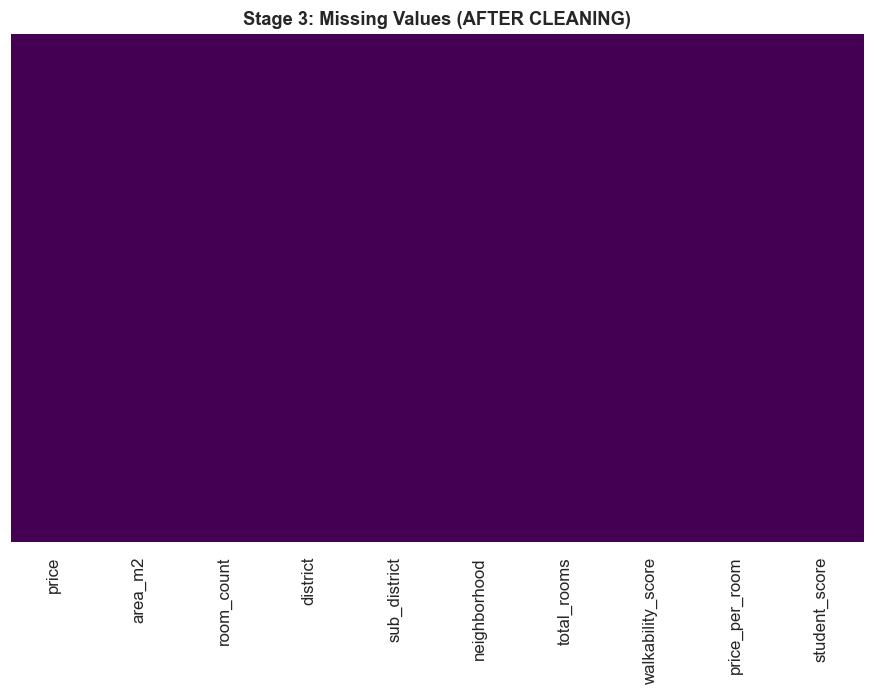

Eksik değer sayısı (Missing values count):

price                0
area_m2              0
room_count           0
district             0
sub_district         0
neighborhood         0
total_rooms          0
walkability_score    0
price_per_room       0
student_score        0
dtype: int64


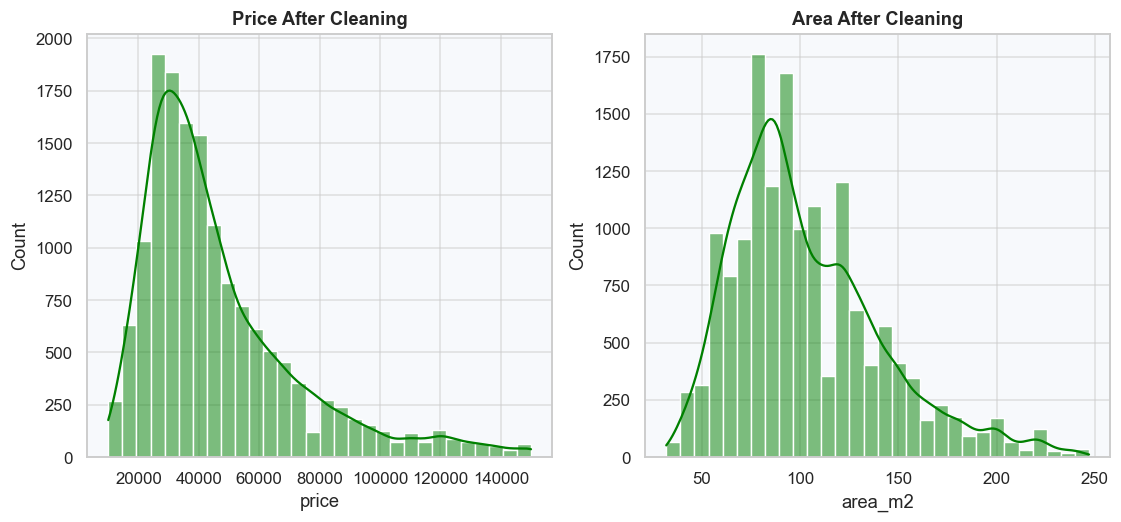

In [19]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Heat Map: Temizlik ve Outlier isleminden sonraki eksik veri görsellestirmesi
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Stage 3: Missing Values (AFTER CLEANING)")

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage3_missing_values.png', dpi=300,bbox_inches='tight')
plt.show()

# Sutun bazinda eksik veri sayilarini tekrar kontrol et. (hepsi 0 olmali)
print("Eksik değer sayısı (Missing values count):\n")
print(df.isnull().sum())

# Temizlik sonrasi dagilim (Yesil = daha duzenli)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True, color='green')
plt.title('Price After Cleaning')

plt.subplot(1, 2, 2)
sns.histplot(df['area_m2'], bins=30, kde=True, color='green')
plt.title('Area After Cleaning')

# Kiyaslama icin png kaydet.
plt.savefig('p1_plots/stage3_final_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

_The uniform purple heatmap confirms a fully complete dataset across all 10 columns (6 raw + 4 engineered). Cleaning has eliminated every missing value, validated district names against the canonical 38-district list, removed duplicates and unrealistic listings, and added the engineered features. The dataset is ML-ready._

### Data Processing Pipeline Summary

The cleaning and engineering pipeline transformed 16,221 raw scraped listings into a clean, ML-ready dataset of 15,272 listings.

---

**Stage 1 → Stage 3: Missing-Value Reduction**

Stage 1 (raw): 1,332 missing values concentrated in the `neighborhood` column.
Stage 3 (final): zero missing values across all 10 columns.

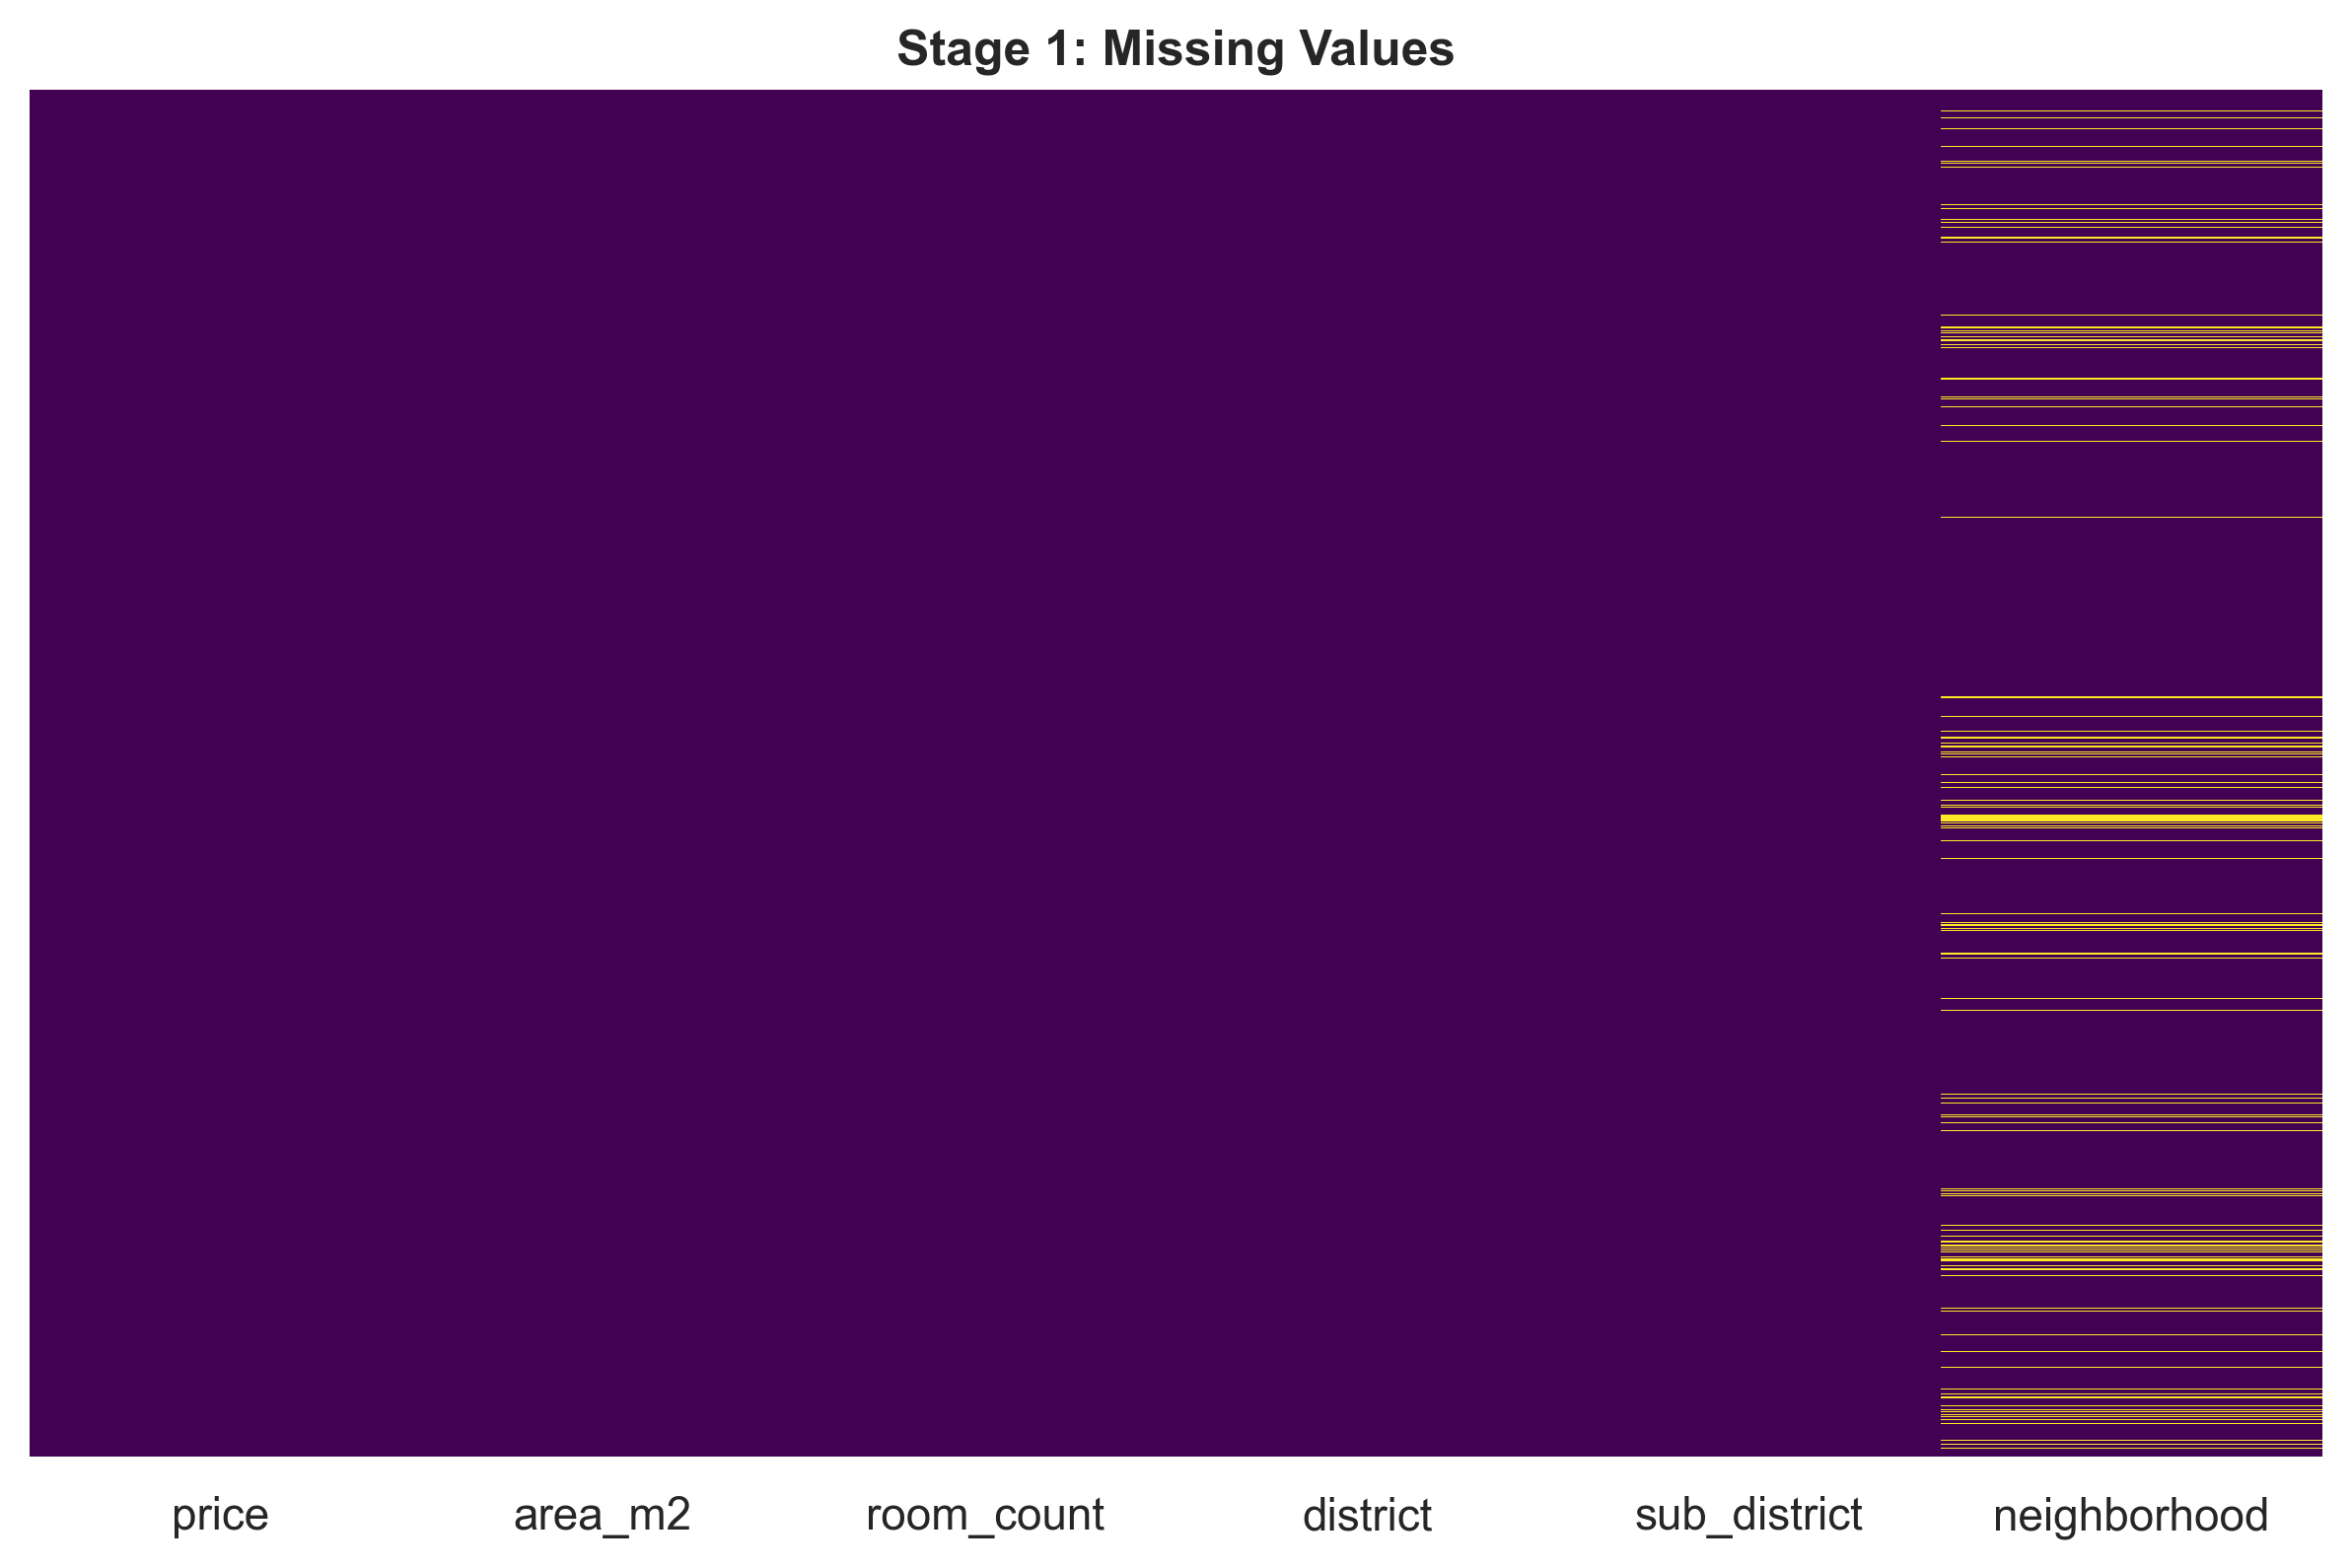

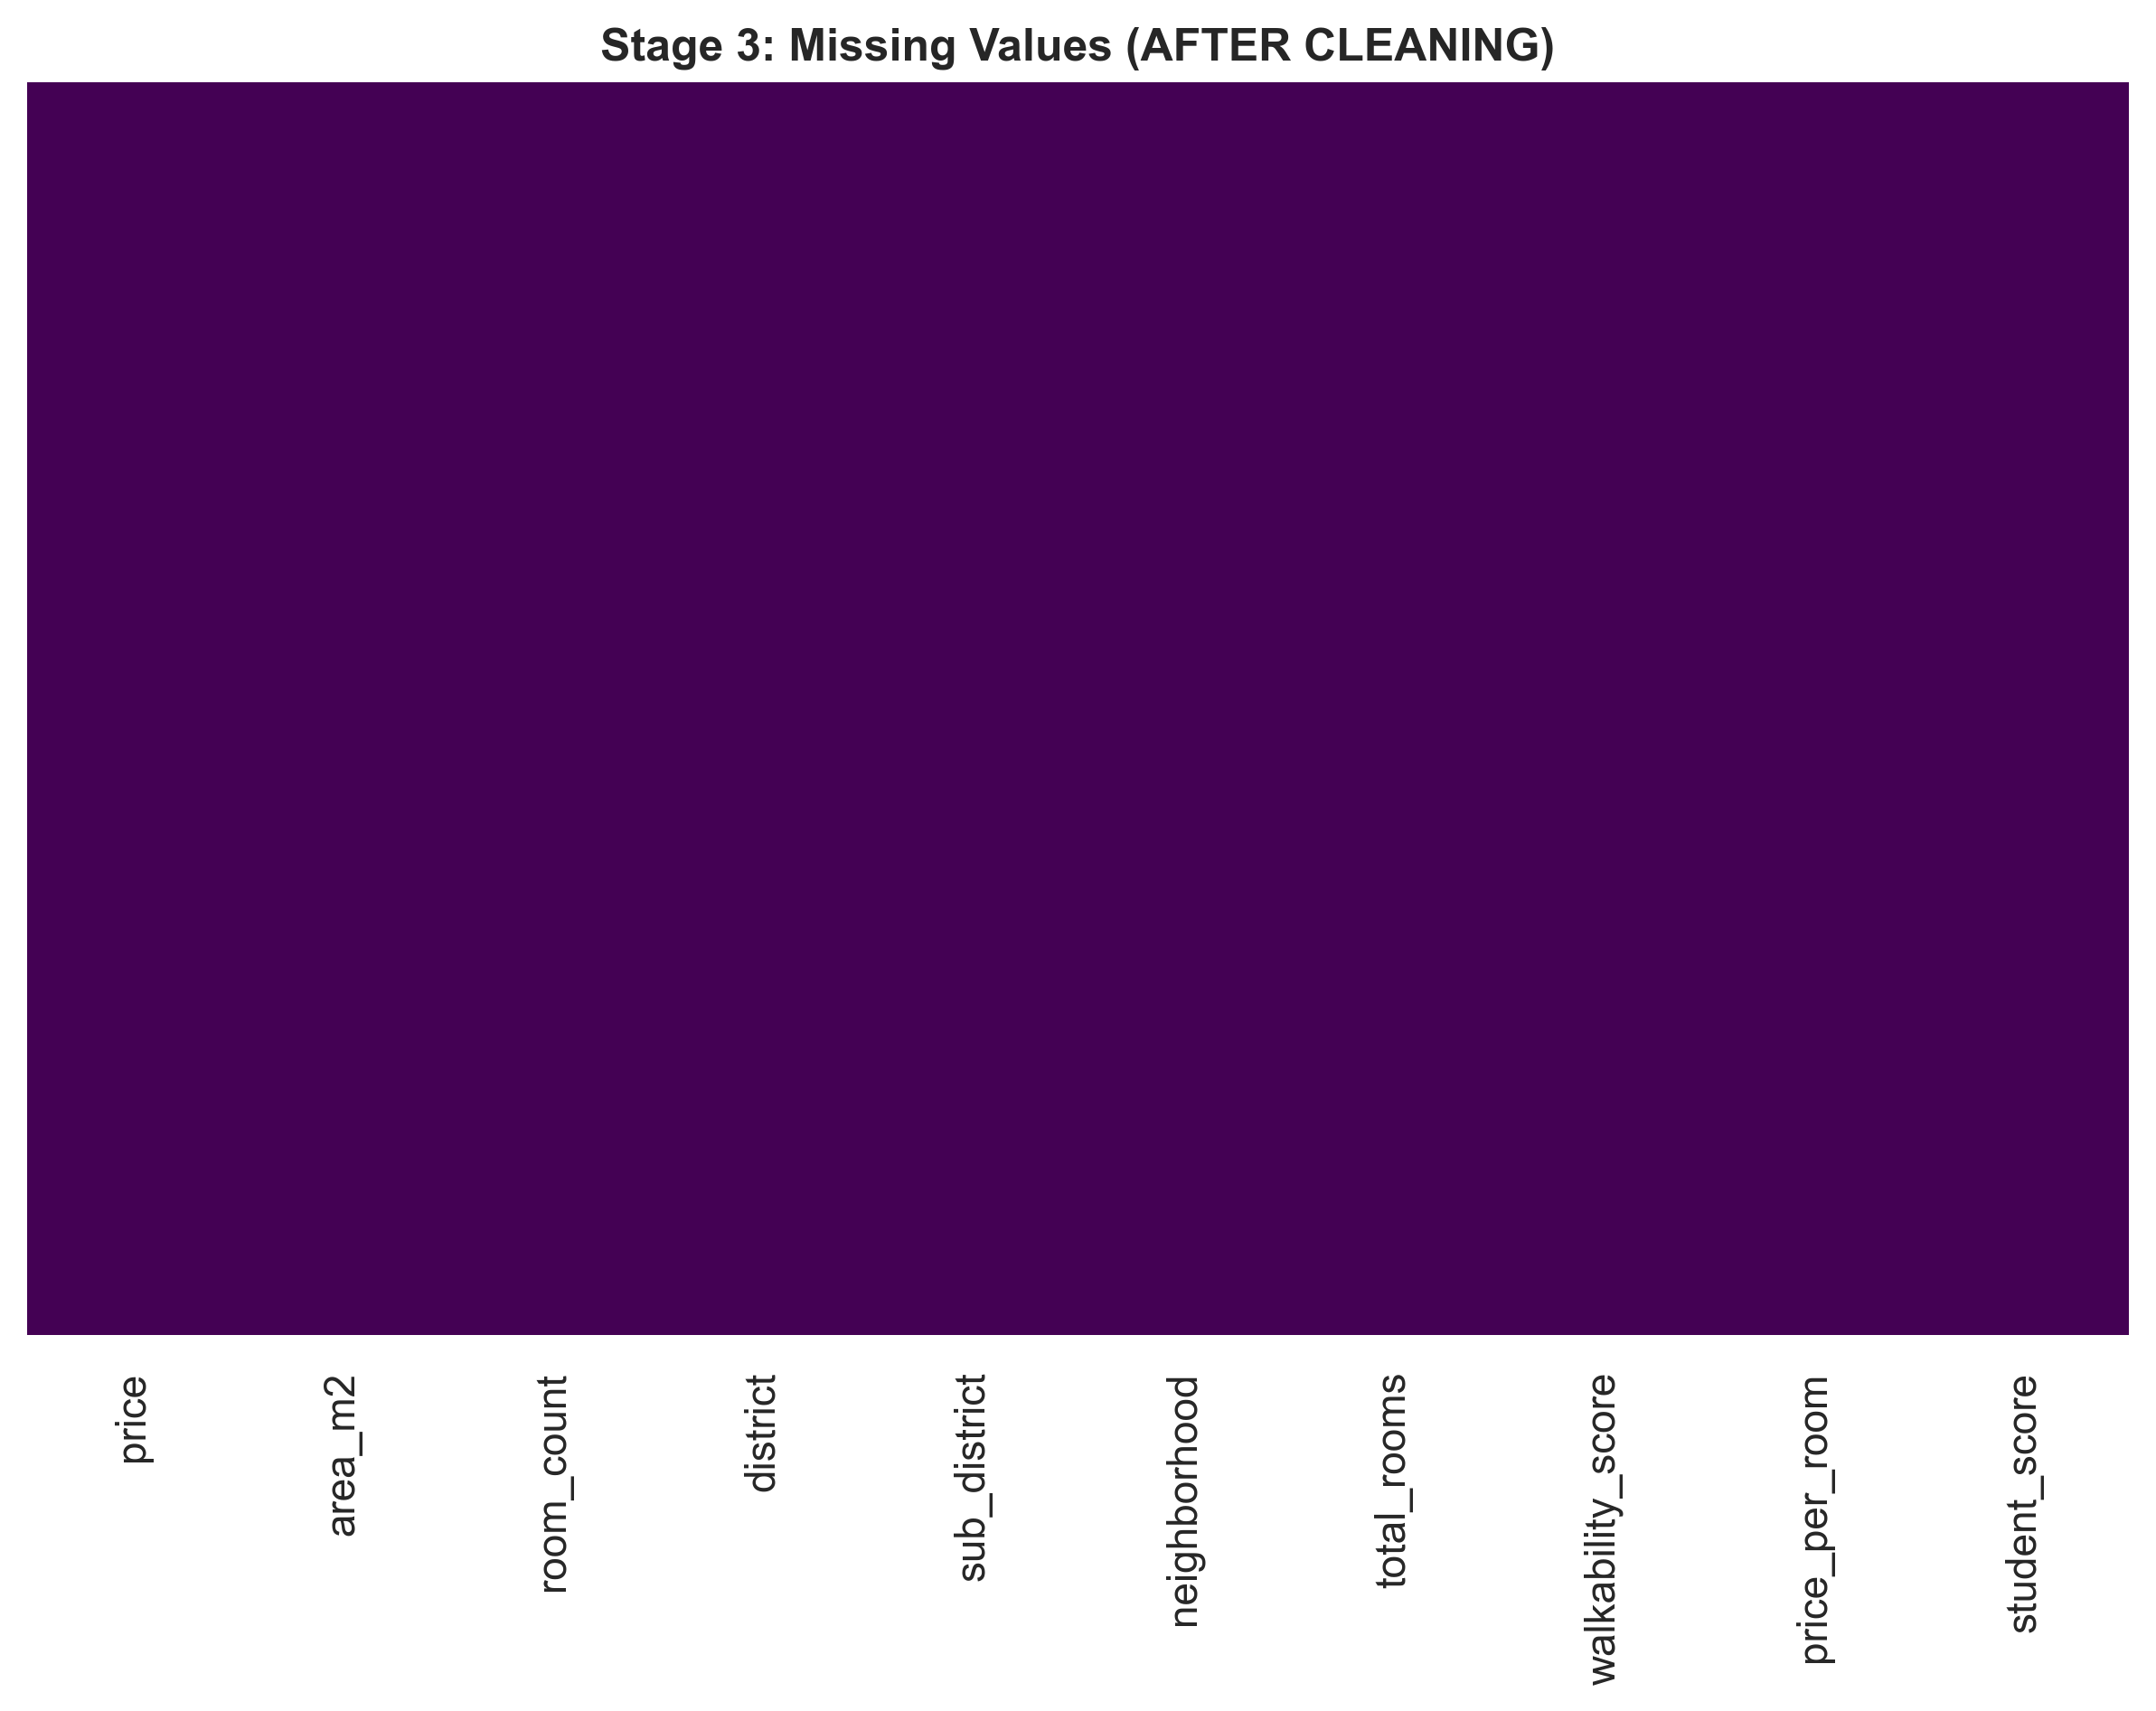

In [20]:
display(Image(filename="p1_plots/stage1_missing_values.png"))
display(Image(filename="p1_plots/stage3_missing_values.png"))



**Stage 2: Pre-Cleaning Distributions**

Before outlier removal, the `price` and `area_m2` distributions showed long right tails consistent with luxury listings and commercial-plot artefacts. Domain-based thresholds (price 10k–150k TL, area 30–250 m², rooms ≤ 6) corrected these.

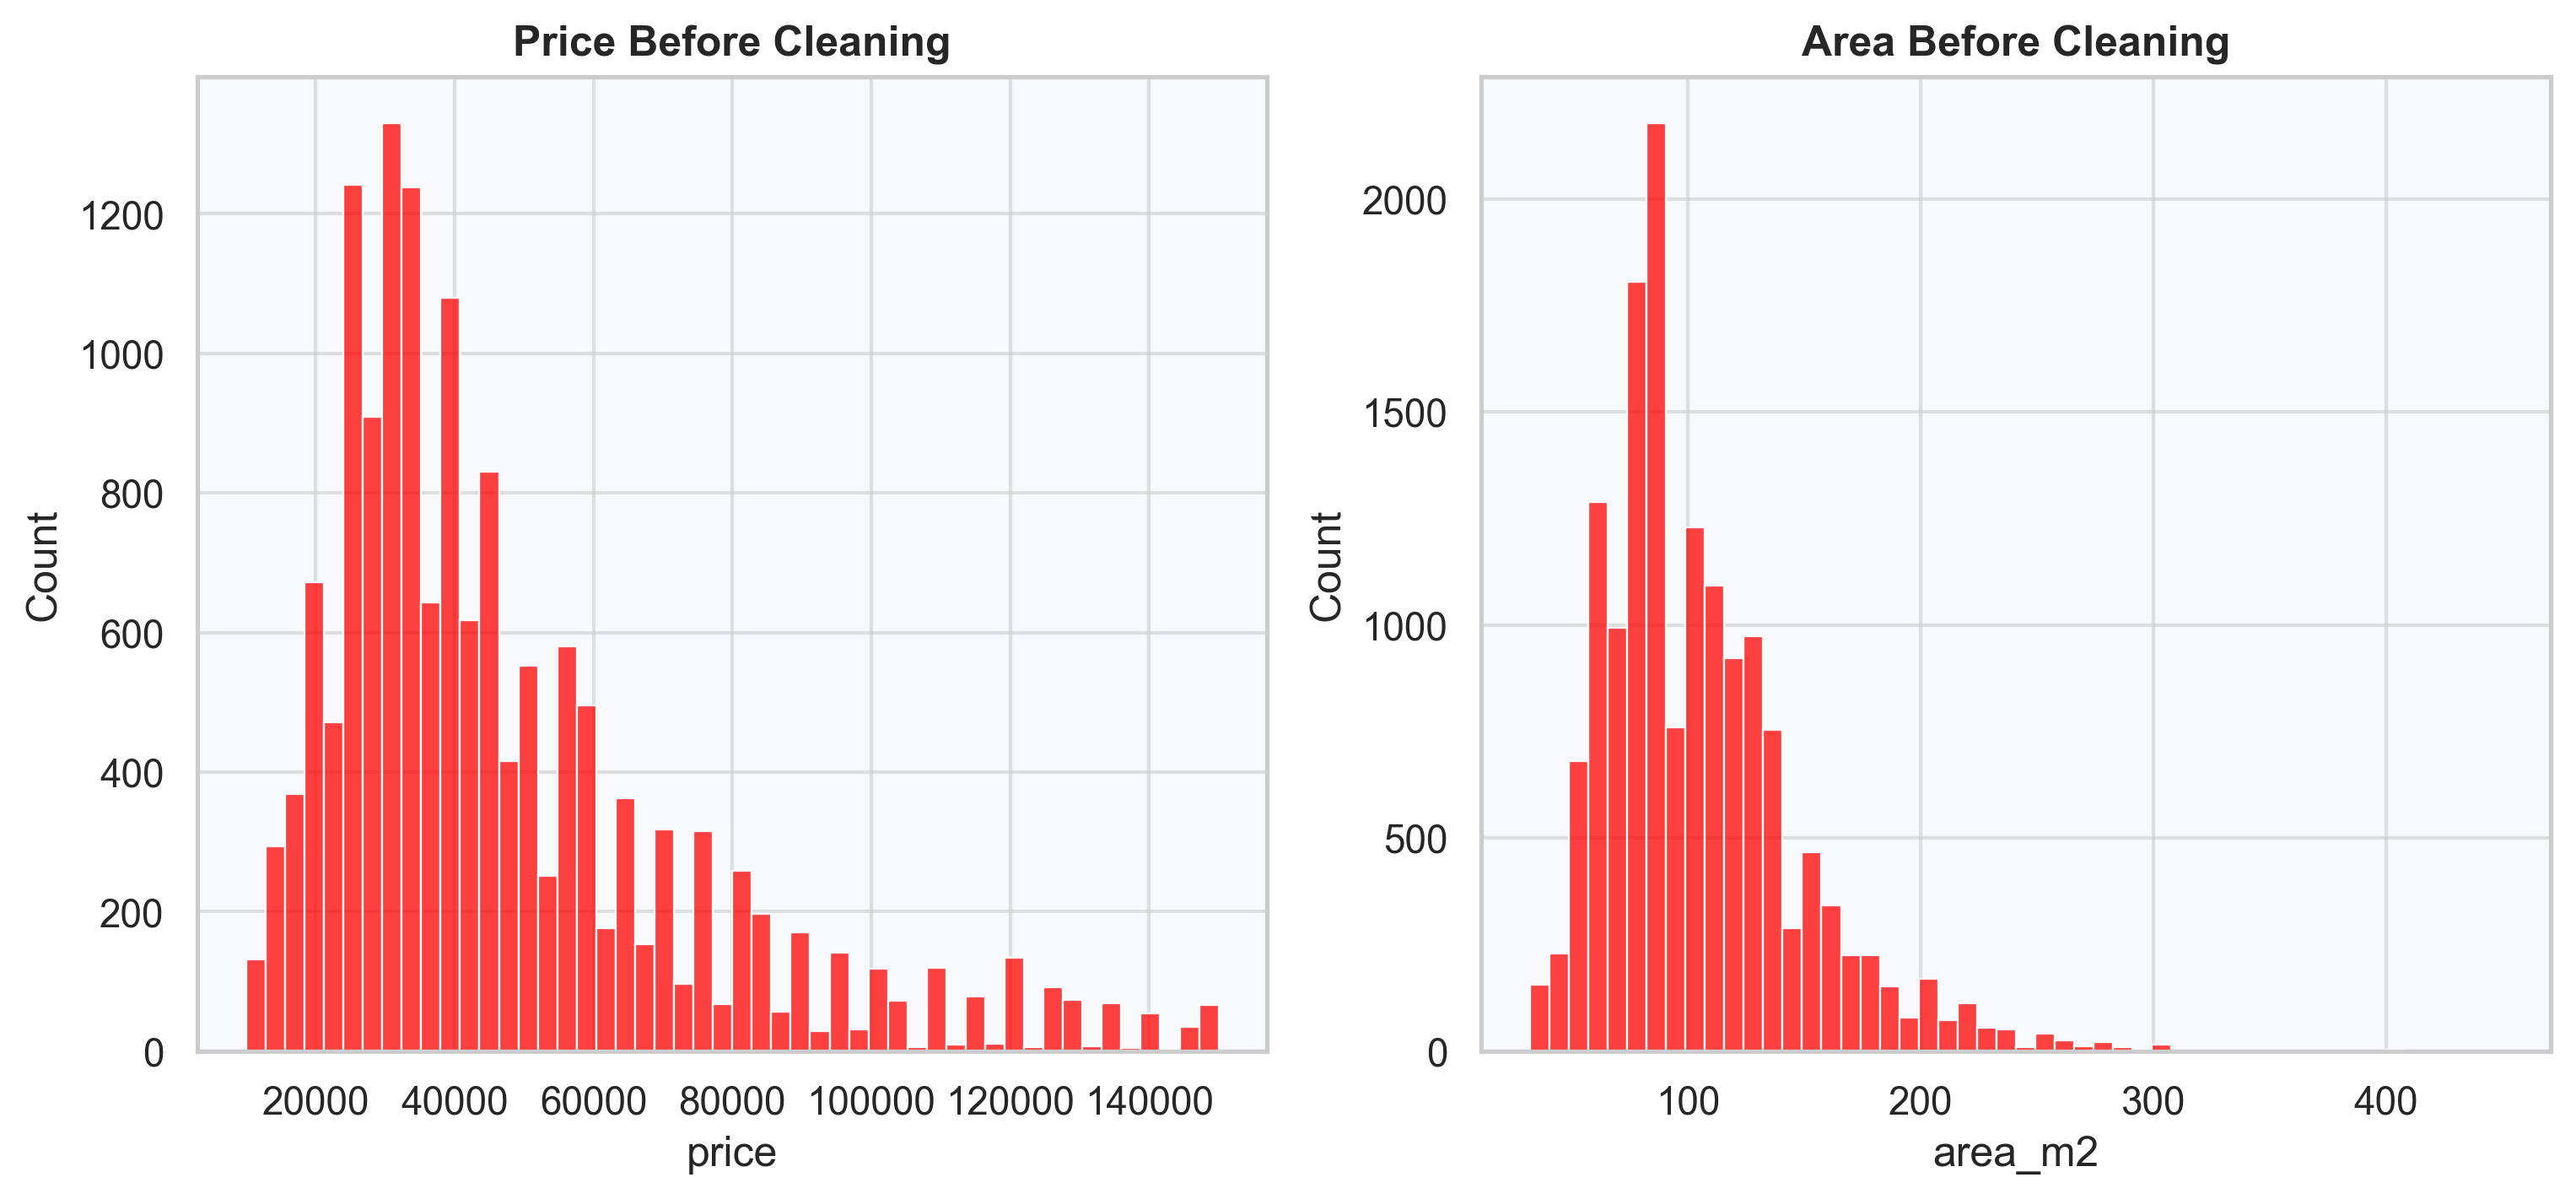

In [21]:
display(Image(filename="p1_plots/stage2_dirty_distribution.png"))


**Final Pipeline Result**

| Stage | Rows | Columns | Notes |
| :--- | :---: | :---: | :--- |
| Raw load | 16,221 | 6 | 1,332 missing in `neighborhood` |
| After dedup + critical dropna | 15,446 | 7 | 775 duplicates removed; `total_rooms` engineered |
| After walkability join | 15,446 | 8 | District-level walkability merged |
| After outlier filter | 15,272 | 9 | Area/room domain thresholds applied |
| After student score | **15,272** | **10** | `price_per_room` + `student_score` added |

---


# 5. Univariate Analysis

In this section, we analyze the distribution and statistical properties of each feature individually.

### **5.1. Numerical Features Analysis: Distribution & Skewness**

To understand each numerical feature's distribution and identify cases where transformation is needed for P2 regression, every variable is visualised with histogram + KDE and summarised with central tendency, spread, and skewness.

**Skewness interpretation rule of thumb:**
* `|skew| < 0.5` → approximately symmetric
* `0.5 ≤ |skew| < 1.0` → moderately skewed
* `|skew| ≥ 1.0` → highly skewed (transformation recommended)

| Feature | Mean | Median | Std Dev | Skewness | Interpretation |
| :--- | ---: | ---: | ---: | ---: | :--- |
| **Price** (target) | 46,352.0 | 39,000.0 | 26,209.5 | **1.546** | **Highly right-skewed.** Long luxury tail pulls mean well above median. Log transformation will be applied in P2 (log skew ≈ 0.228, near-symmetric). |
| **Area (m²)** | 103.1 | 95.0 | 38.3 | 0.956 | Moderately right-skewed. Typical apartments cluster 75–125 m²; tail extends to large units. |
| **Total Rooms** | 3.1 | 3.0 | 0.9 | 0.302 | Approximately symmetric, but discrete — distribution is dominated by integer values 2 and 3 (i.e. 1+1, 2+1, 3+1 configurations). |
| **Walkability Score** | 41.0 | 39.7 | 21.3 | 0.306 | **Discrete multi-modal** distribution with peaks near 20, 40, and 75. This is not a true skew artefact — it reflects that walkability is a **district-level constant**, so all listings in a given district share the same value, producing a small number of large clumps. P2 geocoding will smooth this. |
| **Student Score** | 45.5 | 45.1 | 14.1 | 0.267 | Approximately symmetric and well-formed. The composite construction (walkability + percentile-rank affordability) successfully produces a balanced distribution. |


#### Numerical Features Histogram

Plot saved: p1_plots/5_1_numerical_distributions.png


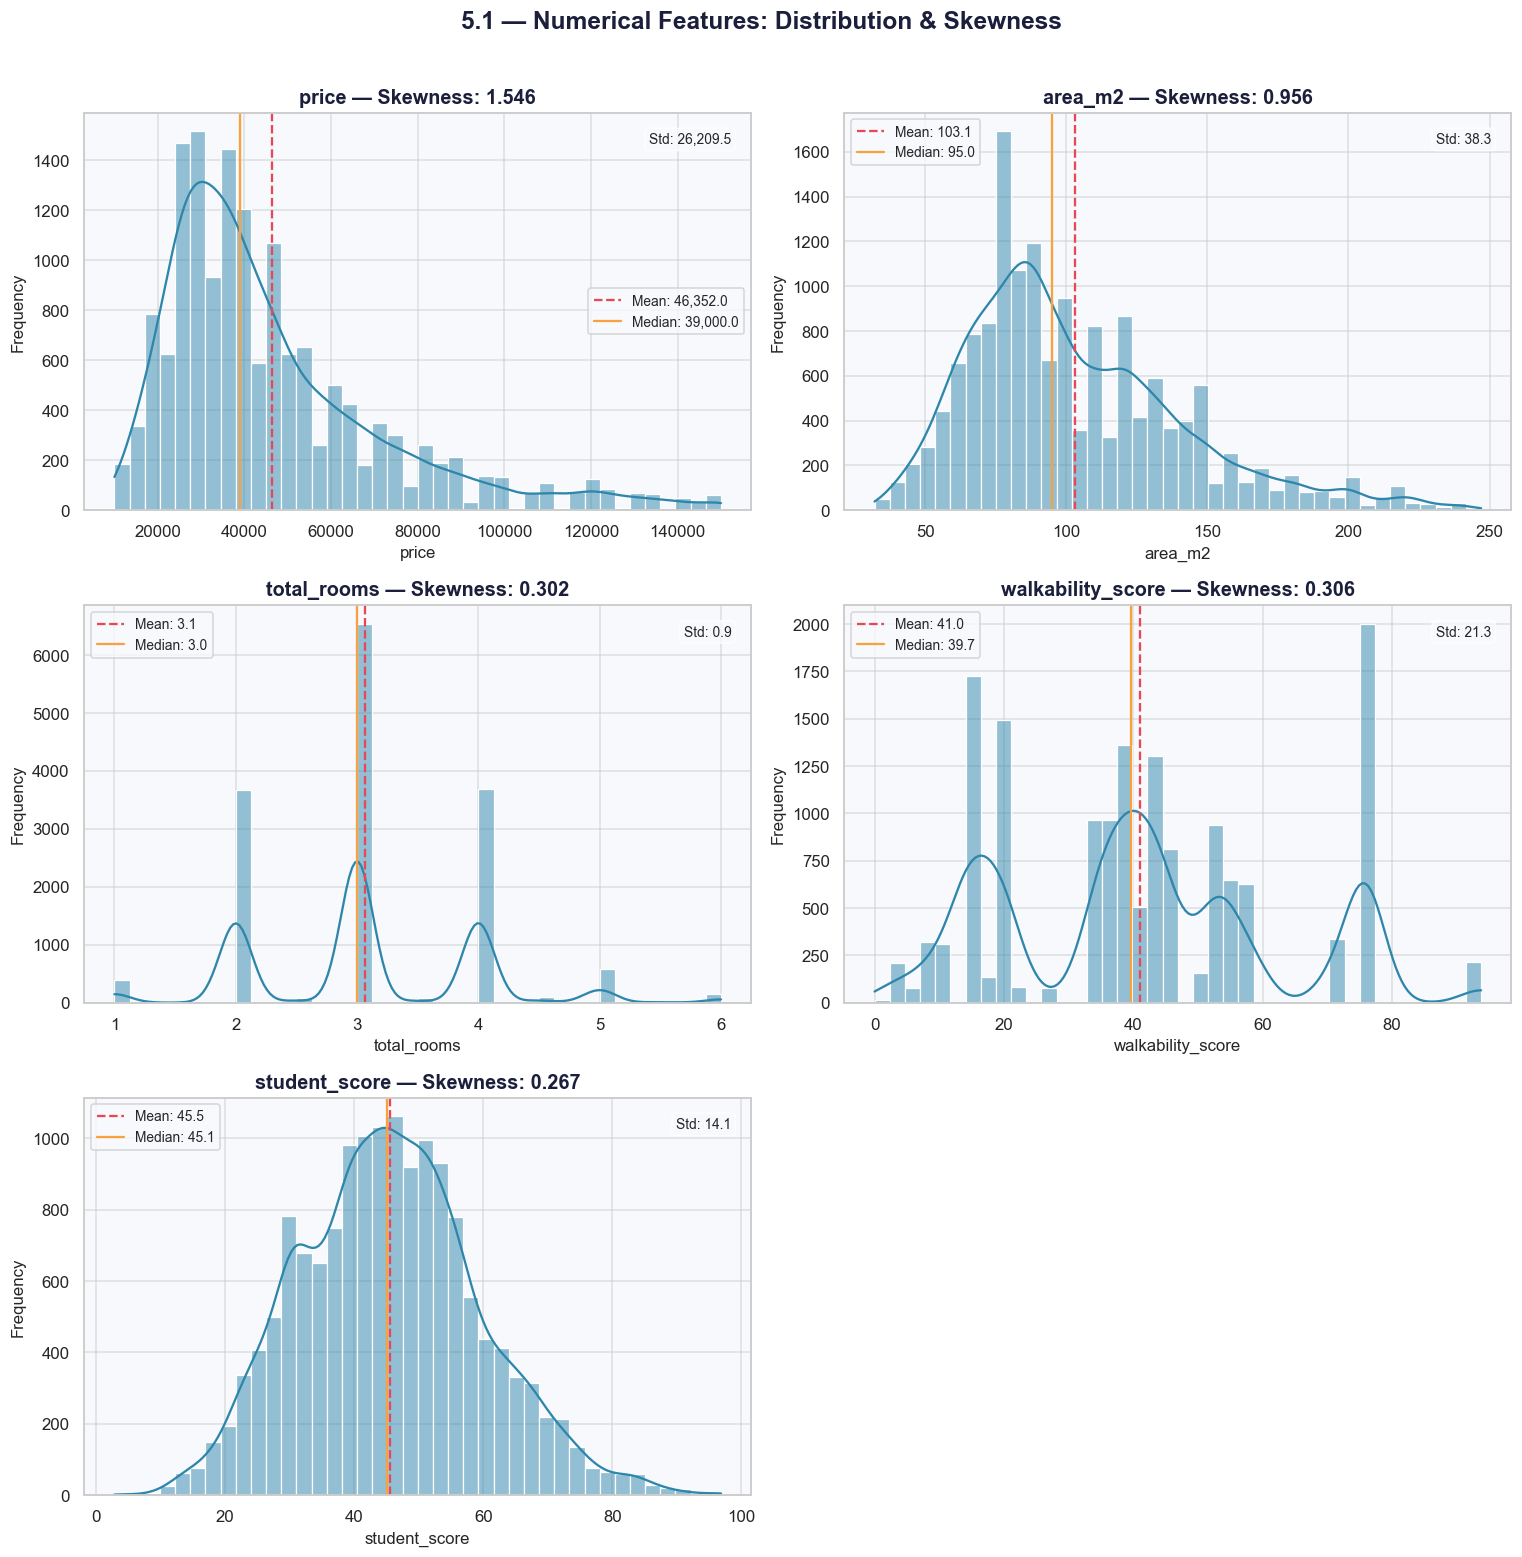

In [22]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

numerical_cols = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color=C_PRIMARY, edgecolor='white')

    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    skew_val = df[col].skew()

    ax.axvline(mean_val, color=C_SECONDARY, linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.1f}')
    ax.axvline(median_val, color=C_ACCENT, linestyle='-', linewidth=1.5, label=f'Median: {median_val:,.1f}')

    ax.set_title(f'{col} — Skewness: {skew_val:.3f}', fontsize=13, fontweight='bold', color=C_DARK)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend(fontsize=9)

    stats_text = f'Std: {std_val:,.1f}'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=C_LIGHT, alpha=0.8))

axes[-1].set_visible(False)

plt.suptitle('5.1 — Numerical Features: Distribution & Skewness', fontsize=16, fontweight='bold', color=C_DARK, y=1.01)
plt.tight_layout()
plt.savefig('p1_plots/5_1_numerical_distributions.png', dpi=150, bbox_inches='tight')
print("Plot saved: p1_plots/5_1_numerical_distributions.png")
plt.show()

In [23]:
# ── Sayisal istatistik ozet tablosu ──
stats_rows = []
for col in numerical_cols:
    stats_rows.append({
        'Feature': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Std Dev': round(df[col].std(), 2),
        'Skewness': round(df[col].skew(), 3),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Feature')
display(stats_df)

,Mean,Median,Std Dev,Skewness,Min,Max
Feature,,,,,,
price,46351.97,39000.00,26209.45,1.546,10000.00,150000.00
area_m2,103.05,95.00,38.26,0.956,32.00,247.00
total_rooms,3.07,3.00,0.92,0.302,1.00,6.00
walkability_score,41.04,39.71,21.26,0.306,0.00,93.75
student_score,45.52,45.13,14.08,0.267,2.86,96.83


### 5.2. Categorical Features Analysis

This section examines the frequency distribution of categorical variables — primarily `district` and `room_count` — to understand the composition of the Istanbul rental market in our cleaned dataset.

**Geographic concentration (top 5 districts by listing count):**

| District | Listings | Share |
| :--- | ---: | ---: |
| Esenyurt | 980 | 6.4% |
| Şişli | 843 | 5.5% |
| Pendik | 815 | 5.3% |
| Ümraniye | 792 | 5.2% |
| Kağıthane | 785 | 5.1% |

The dataset spans all 38 districts, but the top 5 alone account for ~27% of listings. This reflects both real market activity (Esenyurt and Ümraniye are large residential satellite zones) and platform listing behaviour (Şişli's higher digital turnover).

**Housing stock (top 5 room configurations):**

| Configuration | Listings | Share |
| :--- | ---: | ---: |
| 2+1 | 6,526 | 42.7% |
| 1+1 | 3,652 | 23.9% |
| 3+1 | 3,640 | 23.8% |
| 4+1 | 483 | 3.2% |
| Stüdyo (1+0) | 390 | 2.6% |

**Key takeaways:**

* **2+1 dominates** at ~43% — the standard small-family / shared-student configuration.
* **1+1 and 3+1 are roughly tied** (~24% each), indicating the market also serves single tenants and larger families with similar volume.
* **Studio supply is small** (2.6%) — a constraint to keep in mind when interpreting the studio-specific student score statistics in Section 6.3.6.

#### Categorical Features Bar Charts

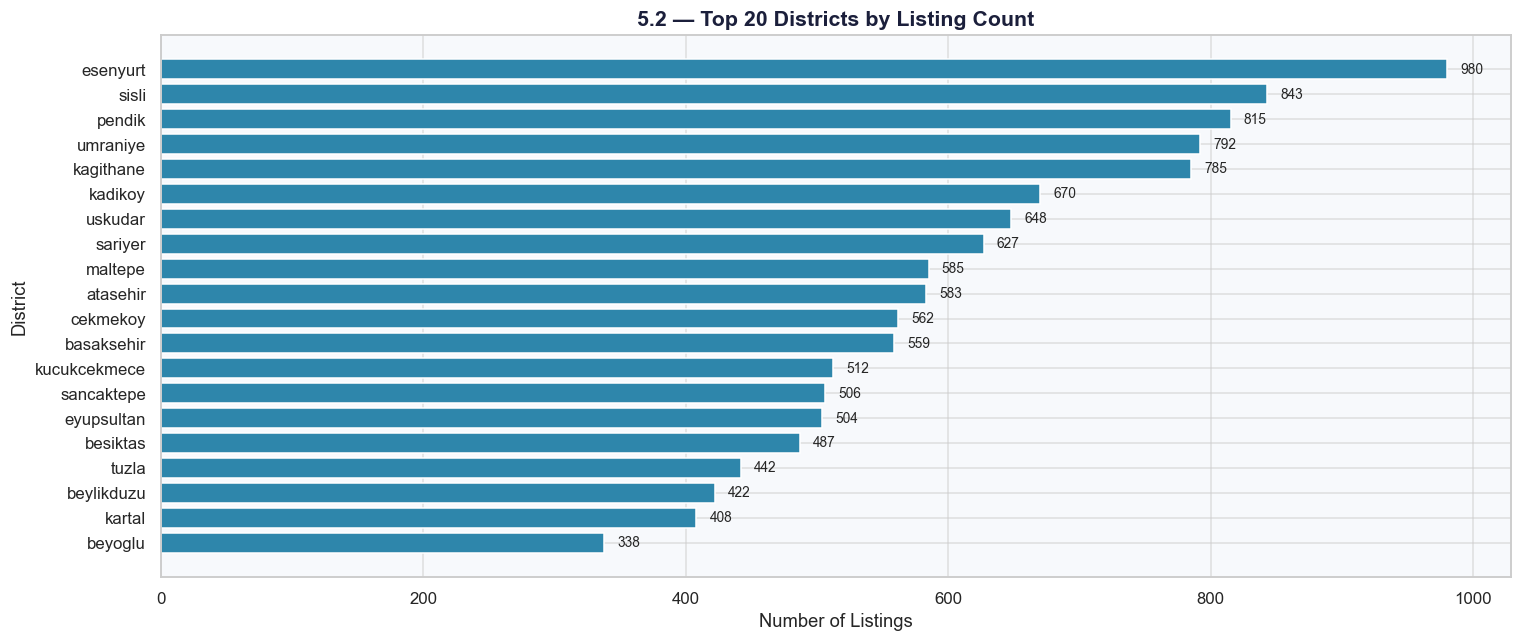

In [24]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# ── İlçe (district) frekans dağılımı ──
district_counts = df['district'].value_counts().head(20)

plt.figure(figsize=(14, 6))
# plt.cm.Blues_r YERİNE ana rengimiz olan C_PRIMARY kullanıyoruz
bars = plt.barh(district_counts.index[::-1], district_counts.values[::-1],
                color=C_PRIMARY, edgecolor='white')

for bar, val in zip(bars, district_counts.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.title('5.2 — Top 20 Districts by Listing Count', fontsize=14, fontweight='bold', color=C_DARK)
plt.xlabel('Number of Listings', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.tight_layout()
plt.savefig('p1_plots/5_2_district_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
print(f"\nTop 5 Districts:")
for dist, cnt in district_counts.head(5).items():
    print(f"  {dist:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Districts:
  esenyurt               980  (6.4%)
  sisli                  843  (5.5%)
  pendik                 815  (5.3%)
  umraniye               792  (5.2%)
  kagithane              785  (5.1%)


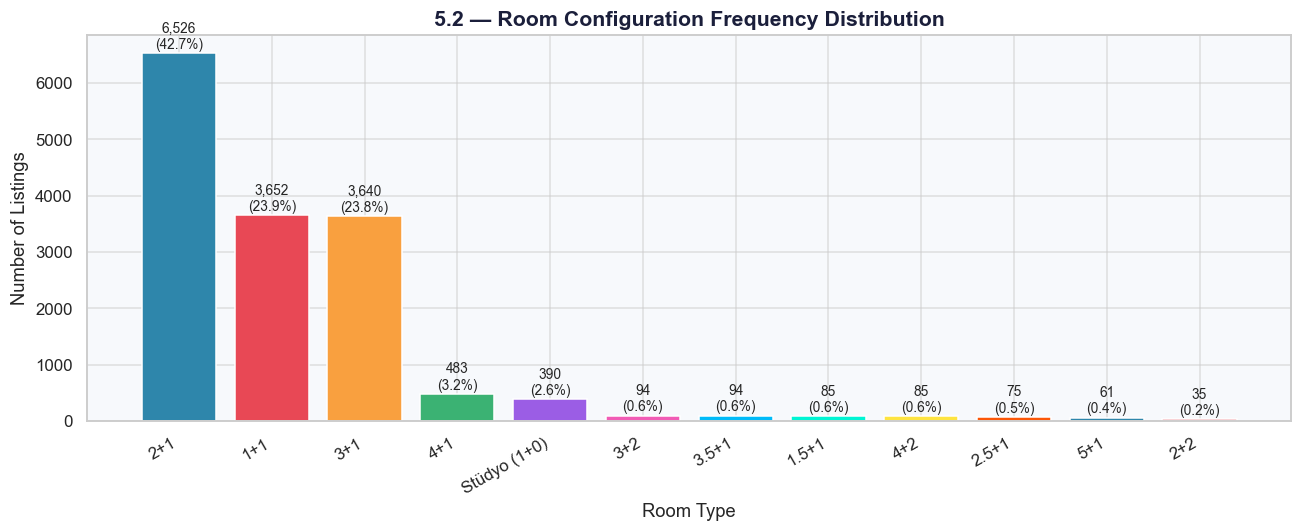

In [26]:
# ── Oda tipi (room_count) frekans dagilimi ──
room_counts = df['room_count'].value_counts().head(12)

plt.figure(figsize=(12, 5))
# plt.cm.Set2 YERİNE özel temamızdaki CAT_PALETTE kullanıyoruz
bars = plt.bar(room_counts.index, room_counts.values,
               color=CAT_PALETTE[:len(room_counts)], edgecolor='white')

for bar, val in zip(bars, room_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title('5.2 — Room Configuration Frequency Distribution', fontsize=14, fontweight='bold', color=C_DARK)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('p1_plots/5_2_room_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print(f"\nTop 5 Room Configurations:")
for rtype, cnt in room_counts.head(5).items():
    print(f"  {rtype:<20} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Top 5 Room Configurations:
  2+1                  6,526  (42.7%)
  1+1                  3,652  (23.9%)
  3+1                  3,640  (23.8%)
  4+1                    483  (3.2%)
  Stüdyo (1+0)           390  (2.6%)


### 5.3. Target Variable Detail: `price`

`price` is the monthly rental cost in TL and is the regression target for P2. Understanding its distribution determines whether a transformation is needed before linear modelling.

**Key statistics:**

* **Count:** 15,272 listings
* **Mean:** 46,352.0 TL
* **Median:** 39,000.0 TL
* **Std Dev:** 26,209.5 TL
* **Skewness:** **1.546** (highly right-skewed)
* **Range:** 10,000 TL – 150,000 TL (domain-filtered at scrape time)

**Distribution shape:** heavily right-skewed. The mean sits ~7,300 TL above the median because the upper tail (premium listings 80k–150k TL) drags the average up. Most listings are concentrated in the 25,000–60,000 TL band.

**Why the median is preferred for descriptive statistics:**
With skew = 1.546, the mean is not a representative "typical rent". Throughout the bivariate analysis (Section 6.3) median rents are used instead, especially for district-level comparisons and the strategic quadrant thresholds.

**Transformation plan for P2:**
`log(1 + price)` brings the skewness down to **0.228** — essentially symmetric. P2 will model `log_price` as the target, which both stabilises variance and makes linear regression coefficients interpretable as approximate percentage effects.

#### Target Variable (price) Detailed Analysis

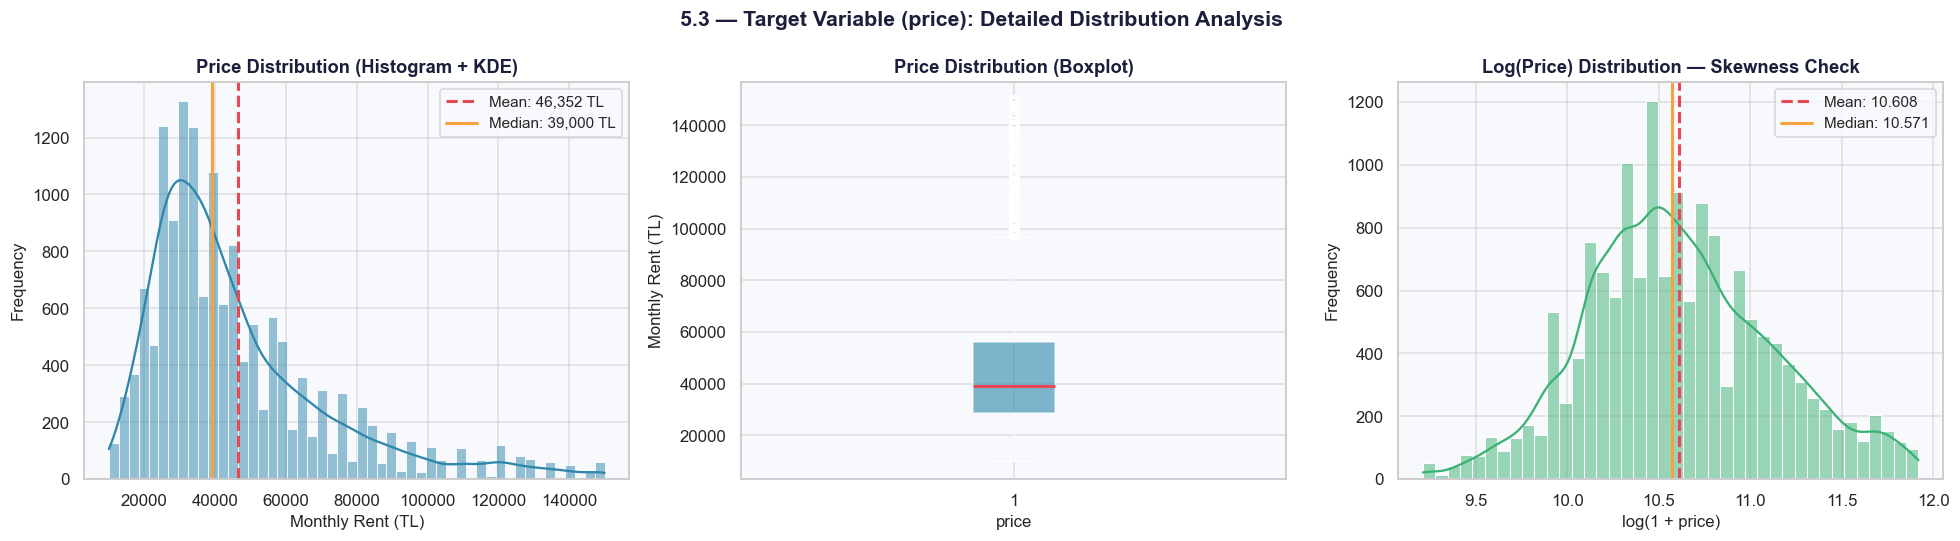

In [28]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Sol: Histogram + KDE ──
ax1 = axes[0]
sns.histplot(df['price'], bins=50, kde=True, ax=ax1, color=C_PRIMARY, edgecolor='white')
ax1.axvline(df['price'].mean(),   color=C_SECONDARY, linestyle='--', lw=2, label=f"Mean: {df['price'].mean():,.0f} TL")
ax1.axvline(df['price'].median(), color=C_ACCENT,    linestyle='-',  lw=2, label=f"Median: {df['price'].median():,.0f} TL")
ax1.set_title('Price Distribution (Histogram + KDE)', fontsize=12, fontweight='bold', color=C_DARK)
ax1.set_xlabel('Monthly Rent (TL)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(fontsize=10)

# ── Orta: Boxplot ──
ax2 = axes[1]
ax2.boxplot(df['price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor=C_PRIMARY, alpha=0.6),
            medianprops=dict(color=C_SECONDARY, linewidth=2))
ax2.set_title('Price Distribution (Boxplot)', fontsize=12, fontweight='bold', color=C_DARK)
ax2.set_ylabel('Monthly Rent (TL)', fontsize=11)
ax2.set_xlabel('price', fontsize=11)

# ── Sag: Log-transformed histogram ──
ax3 = axes[2]
import numpy as np
log_price = np.log1p(df['price'])
sns.histplot(log_price, bins=40, kde=True, ax=ax3, color=C_GREEN, edgecolor='white')
ax3.axvline(log_price.mean(),   color=C_SECONDARY, linestyle='--', lw=2, label=f"Mean: {log_price.mean():.3f}")
ax3.axvline(log_price.median(), color=C_ACCENT,    linestyle='-',  lw=2, label=f"Median: {log_price.median():.3f}")
ax3.set_title('Log(Price) Distribution — Skewness Check', fontsize=12, fontweight='bold', color=C_DARK)
ax3.set_xlabel('log(1 + price)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.legend(fontsize=10)

plt.suptitle('5.3 — Target Variable (price): Detailed Distribution Analysis', fontsize=14, fontweight='bold', color=C_DARK)
plt.tight_layout()
plt.savefig('p1_plots/5_3_target_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Istatistik Ozeti ──
print("=== Target Variable (price) — Key Statistics ===")
print(f"  Count     : {len(df['price']):,}")
print(f"  Mean      : {df['price'].mean():>12,.1f} TL")
print(f"  Median    : {df['price'].median():>12,.1f} TL")
print(f"  Std Dev   : {df['price'].std():>12,.1f} TL")
print(f"  Skewness  : {df['price'].skew():>12.3f}")
print(f"  Min       : {df['price'].min():>12,.1f} TL")
print(f"  Max       : {df['price'].max():>12,.1f} TL")
print(f"  Range     : 10,000 TL — 150,000 TL ")
print(f"\nLog(price) Skewness: {log_price.skew():.3f}  ← near-zero = Log Transform recommended for P2")

=== Target Variable (price) — Key Statistics ===
  Count     : 15,272
  Mean      :     46,352.0 TL
  Median    :     39,000.0 TL
  Std Dev   :     26,209.5 TL
  Skewness  :        1.546
  Min       :     10,000.0 TL
  Max       :    150,000.0 TL
  Range     : 12,000 TL — 150,000 TL (domain-filtered)

Log(price) Skewness: 0.228  ← near-zero = Log Transform recommended for P2


# 6. Bivariate & Multivariate Analysis

In this section, we explore the relationships between our features and the target variable (`price`). We aim to identify which factors are the strongest predictors of rental costs in Istanbul.


### 6.1 Correlation Heatmaps

### Correlation heatmap for numerical features

The heatmap below visualizes the Pearson correlation coefficients between numerical variables. This allows us to detect multi-collinearity and understand the linear strength of relationships.

* **Positive Correlation:** As one variable increases, the other tends to increase (e.g., Area vs. Price).
* **Negative Correlation:** As one variable increases, the other tends to decrease (e.g., Price vs. Student Score—since lower prices yield higher student scores).

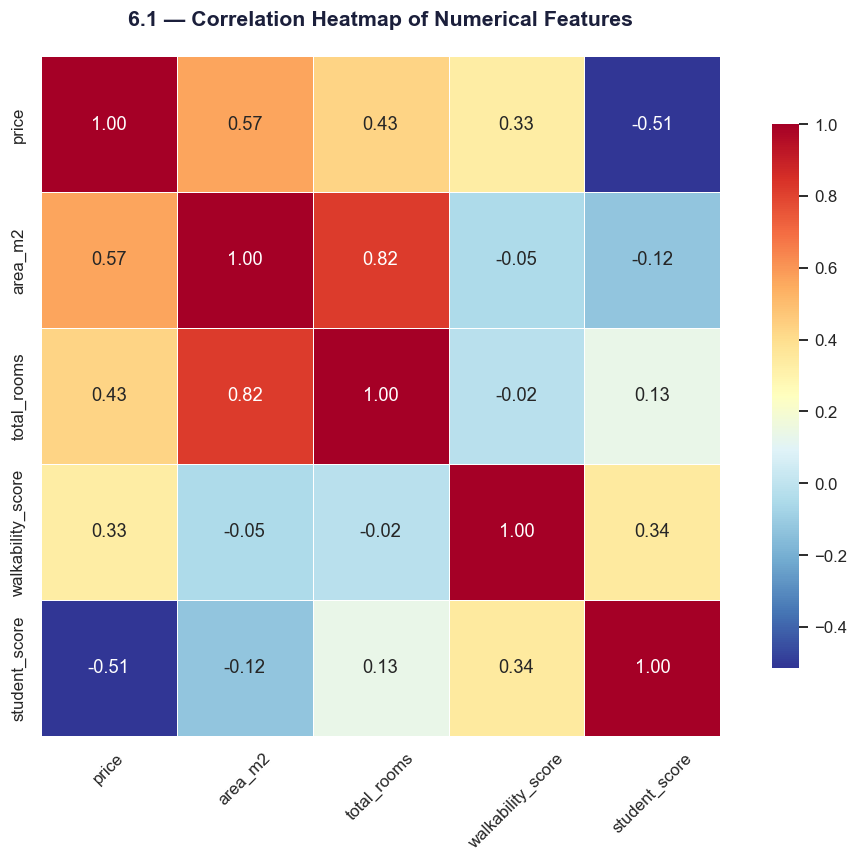

In [30]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Korelasyon matrisini hesapla
# Eklenen ozel metrikleri de dahil ediyoruz
cols_to_corr = ['price', 'area_m2', 'total_rooms', 'walkability_score', 'student_score']
corr_matrix = df[cols_to_corr].corr()

# Grafik alanini olustur
plt.figure(figsize=(10, 8))

# Heatmap cizimi
sns.heatmap(corr_matrix,
            annot=True,
            cmap=CMAP_DIV,
            fmt=".2f",
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .8})

plt.title('6.1 — Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', color=C_DARK, pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('p1_plots/6_1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Onemli iliskiler
print("--- Strongest Correlations with Price ---")
print(corr_matrix['price'].sort_values(ascending=False))

--- Strongest Correlations with Price ---
price                1.000000
area_m2              0.565336
total_rooms          0.427820
walkability_score    0.330423
student_score       -0.513491
Name: price, dtype: float64


**Observations on Relationships**

The Pearson correlation matrix produces the following key relationships with the target:

| Feature | Correlation with `price` | Reading |
| :--- | ---: | :--- |
| `area_m2` | **+0.565** | Strongest single predictor. Larger units cost more, as expected. |
| `total_rooms` | **+0.428** | Secondary structural signal. Note that `area_m2` and `total_rooms` are themselves highly correlated (0.82), so they convey overlapping information — multicollinearity to address in P2. |
| `walkability_score` | **+0.330** | Moderate positive — walkable districts command rent premiums, but the relationship is far from deterministic at the district-level resolution available in P1. |
| `student_score` | **−0.513** | Strong negative, **by construction**. The score formula is `0.5 × walkability + 0.5 × (1 − rank(price_per_room))`, so high prices mechanically depress affordability and therefore student_score. This is consistency, not a discovered pattern. |

**Multicollinearity flag for P2:**
`area_m2` ↔ `total_rooms` correlation of **0.82** is high enough to cause unstable coefficients in plain multiple regression. P2 will address this through one or more of: VIF-based feature selection, regularisation (Ridge/Lasso), or replacing one of the two with an interaction/derived feature.

### Relationship between Walkability and Rent Prices (Correlation Heatmap)
We want to see if "Walkable" districts are more expensive.Central districts like Beşiktaş, Kadıköy, and Şişli command higher rents partly due to their walkability. We want to quantify whether walkability is a primary price driver or one of many factors.

A **Correlation Matrix** is a table that shows the numerical relationship between variables.
The correlation coefficient ranges from **-1 to 1**:

* Near 1.0 (Red): Strong positive relationship. If one variable increases, the other also increases.
* Near 0.0: No relationship between the variables.
* Near -1.0 (Blue): Strong negative relationship. If one increases, the other decreases.

**Why are we doing this?**
We want to see the "Impact Power" of our **Walkability Score** on the **Price**.
If the number is high (above 0.50), it proves our student-friendly scoring is a major factor in Istanbul's housing market.

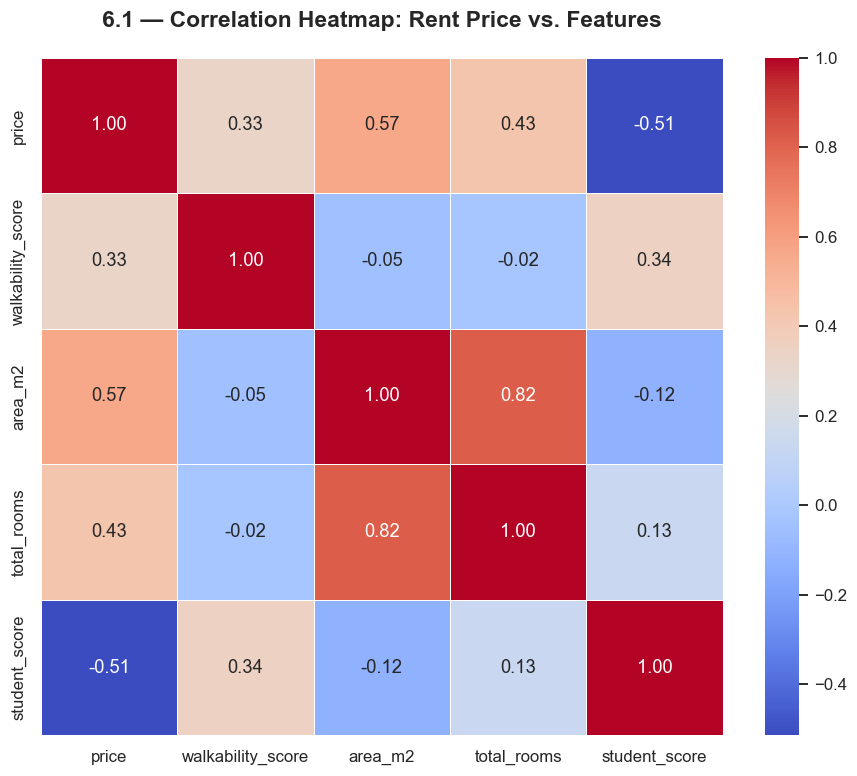

In [32]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Sutunların sayisal oldugundan emin ol.
cols_to_use = ['price', 'walkability_score', 'area_m2', 'total_rooms' , 'student_score' ]
for col in cols_to_use:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sadece bu sutunları iceren ve eksik verisi olmayan bir alt kume al.
corr_data = df[cols_to_use].dropna()

# Korelasyon hesapla.
correlation = corr_data.corr()

# Gorsellestirme
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('6.1 — Correlation Heatmap: Rent Price vs. Features', fontsize=15, pad=20)

plt.savefig('p1_plots/6_1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# Korelasyon katsayisini yorumla.
walk_corr = correlation.loc['price', 'walkability_score']
print(f"\nYürünebilirlik ve fiyat arasındaki korelasyon: {walk_corr:.2f}")

if walk_corr > 0.5:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerinde güçlü bir pozitif etkisi var.")
elif walk_corr > 0.2:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.")
else:
    print("Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi (doğrusal olarak) düşük seviyede kalmıştır.")

std_corr = correlation.loc['price', 'student_score']
print(f"\nStudent Score ve fiyat arasındaki korelasyon: {std_corr:.2f}")

if std_corr < -0.5:
    print("Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.")
elif std_corr < -0.2:
    print("Sonuç: Öğrenciye uygunlukta kira fiyatlarından başka etkenler de önemini korumakta.")
else:
    print("Sonuç: Öğrenciye uygunluğun belirlenmesinde kira fiyatları etkili olmamış.")


Yürünebilirlik ve fiyat arasındaki korelasyon: 0.33
Sonuç: Yürünebilirliğin kira fiyatları üzerindeki etkisi orta seviyededir.

Student Score ve fiyat arasındaki korelasyon: -0.51
Sonuç: Öğrenciye uygunluk ağırlıklı olarak kira fiyatları üzerinden şekillenmiş.


In [34]:
print("=== P2 İçin Kritik Korelasyon Bulguları ===")

# Alan ve Oda Sayısı Arasındaki Multicollinearity
area_rooms_corr = df['area_m2'].corr(df['total_rooms'])
print(f"area_m2 ↔ total_rooms       : {area_rooms_corr:+.3f}  (P2 için Ridge/Lasso sinyali)")

# Toplam Oda Sayısının Fiyata Etkisi
rooms_price_corr = df['total_rooms'].corr(df['price'])
print(f"total_rooms ↔ price         : {rooms_price_corr:+.3f}")

# Oda Başı Maliyet ve Fiyat İlişkisi
ppr_price_corr = df['price_per_room'].corr(df['price'])
print(f"price_per_room ↔ price      : {ppr_price_corr:+.3f}  (Yüksek fiyatlı evler, kişi başına da çok pahalı)")

# Öğrenci Skorunun Dinamikleri (Trade-off İspatı)
student_ppr_corr = df['student_score'].corr(df['price_per_room'])
student_walk_corr = df['student_score'].corr(df['walkability_score'])

print("\n=== Student Score İç Dinamikleri ===")
print(f"student_score ↔ price_per_room : {student_ppr_corr:+.3f}  (Formülün ana itici gücü)")
print(f"student_score ↔ walkability    : {student_walk_corr:+.3f}  (Formülün ikincil itici gücü)")

=== P2 İçin Kritik Korelasyon Bulguları ===
area_m2 ↔ total_rooms       : +0.819  (P2 için Ridge/Lasso sinyali)
total_rooms ↔ price         : +0.428
price_per_room ↔ price      : +0.804  (Yüksek fiyatlı evler, kişi başına da çok pahalı)

=== Student Score İç Dinamikleri ===
student_score ↔ price_per_room : -0.648  (Formülün ana itici gücü)
student_score ↔ walkability    : +0.344  (Formülün ikincil itici gücü)


---
### 6.2 Scatter Plots/Box Plots of The Top Features vs. The Target

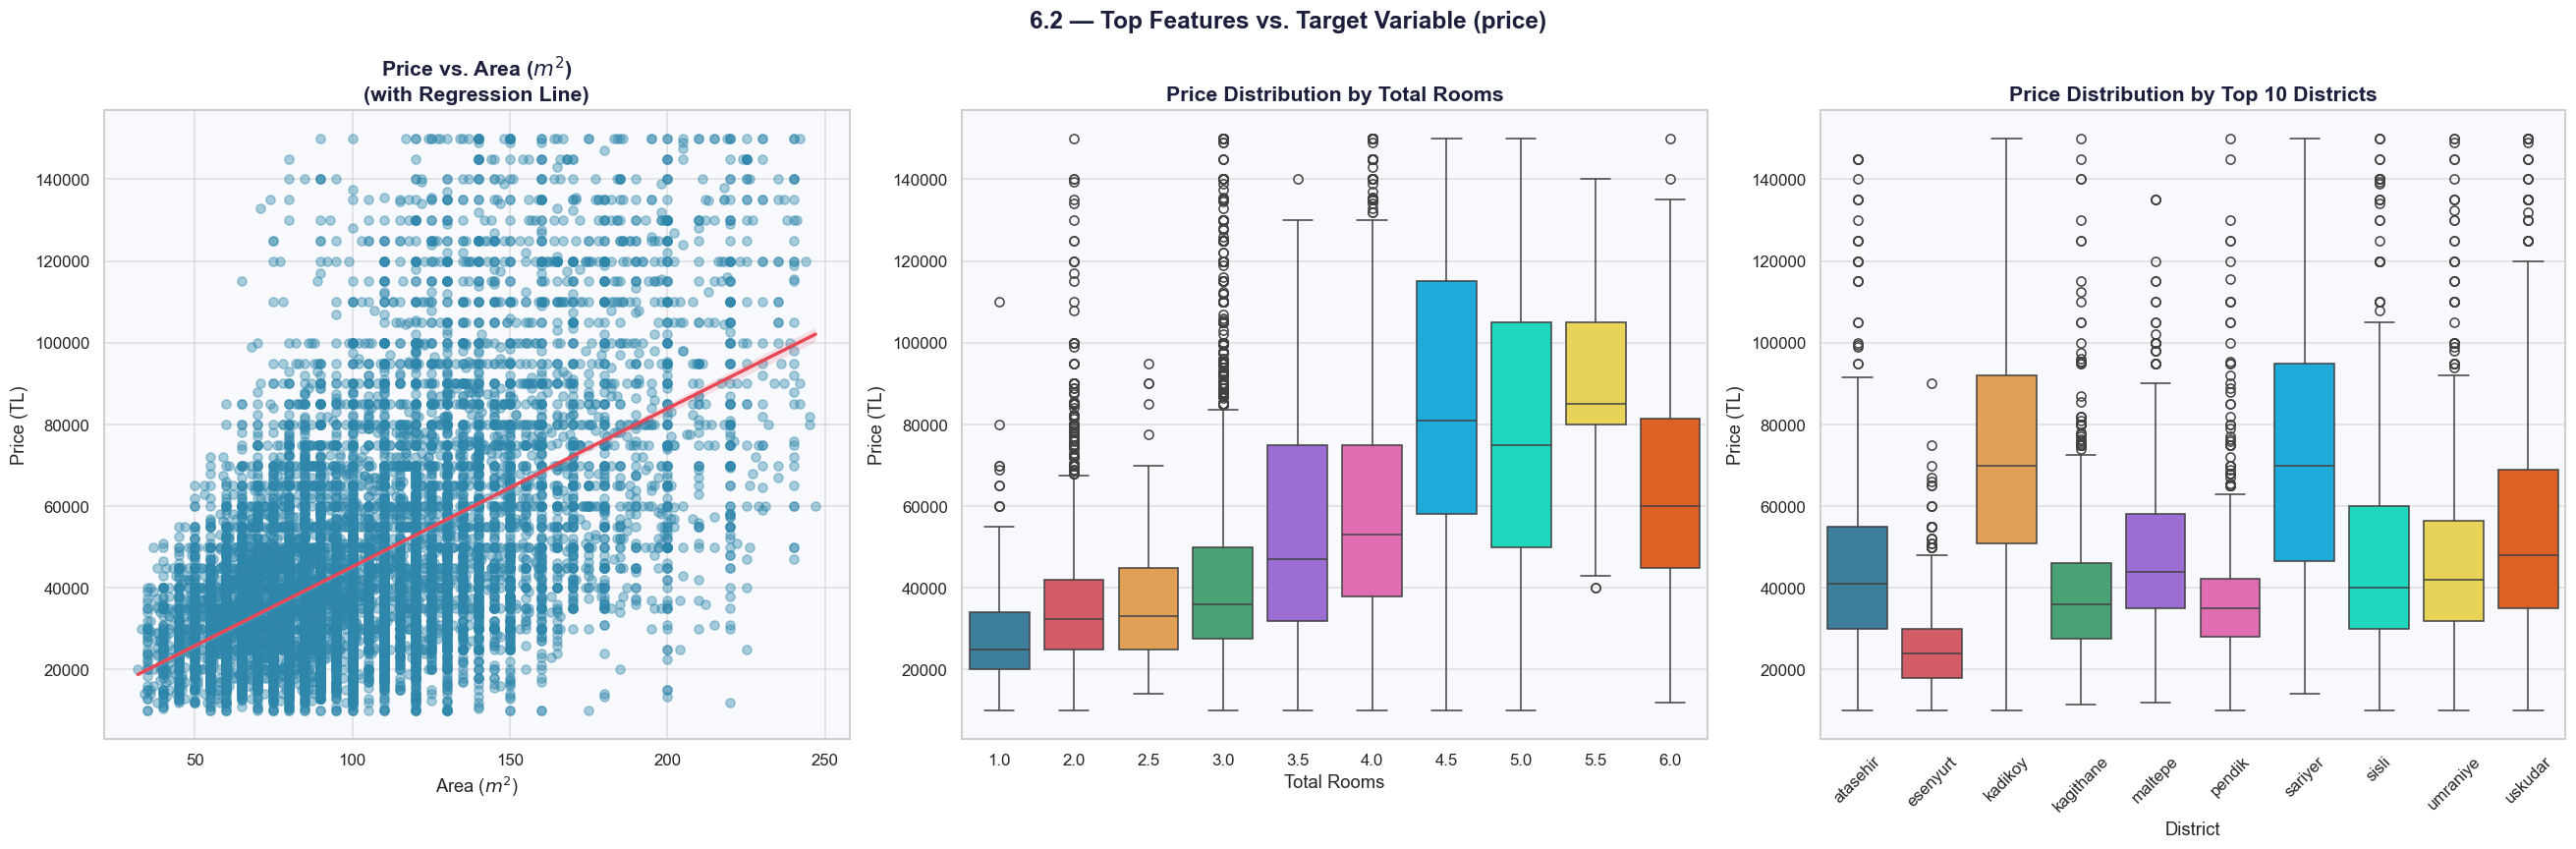

In [35]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Scatter Plot: Alan (m2) ve Fiyat (Sayisal iliski)
sns.regplot(data=df, x='area_m2', y='price', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color': C_PRIMARY},
            line_kws={'color': C_SECONDARY})
axes[0].set_title('Price vs. Area ($m^2$)\n(with Regression Line)', fontsize=14, fontweight='bold', color=C_DARK)
axes[0].set_xlabel('Area ($m^2$)', fontsize=12)
axes[0].set_ylabel('Price (TL)', fontsize=12)

# Box Plot: Toplam Oda Sayisi ve Fiyat
top_10_rooms = df['total_rooms'].value_counts().head(10).index
df_top_rooms = df[df['total_rooms'].isin(top_10_rooms)]

sns.boxplot(data=df_top_rooms, x='total_rooms', y='price', ax=axes[1],
            hue='total_rooms', palette=CAT_PALETTE, legend=False)
axes[1].set_title('Price Distribution by Total Rooms', fontsize=14, fontweight='bold', color=C_DARK)
axes[1].set_xlabel('Total Rooms', fontsize=12)
axes[1].set_ylabel('Price (TL)', fontsize=12)

# Box Plot: En Cok Ilan Verilen 10 Ilce ve Fiyat
top_10_districts = df['district'].value_counts().head(10).index
df_top_districts = df[df['district'].isin(top_10_districts)]

sns.boxplot(data=df_top_districts, x='district', y='price', ax=axes[2],
            hue='district', palette=CAT_PALETTE, legend=False)
axes[2].set_title('Price Distribution by Top 10 Districts', fontsize=14, fontweight='bold', color=C_DARK)
axes[2].set_xlabel('District', fontsize=12)
axes[2].set_ylabel('Price (TL)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('6.2 — Top Features vs. Target Variable (price)', fontsize=16, fontweight='bold', color=C_DARK)
plt.tight_layout()
plt.savefig('p1_plots/6_2_bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**A) Price vs. Area (m²) — Scatter Plot with Regression Line**

* **Purpose:** Visualise the relationship between the strongest numerical predictor and the target.
* **Observation:** The OLS regression line slopes clearly upward, consistent with the +0.565 correlation. Larger apartments rent for more.
* **Heteroskedasticity warning:** The vertical spread of points grows with `area_m2`. Variance in monthly rent is much wider for 150+ m² apartments than for compact units. This violates the constant-variance assumption of plain linear regression and motivates the log transformation planned for P2.

---

**B) Price Distribution by Total Rooms — Box Plot**

* **Purpose:** Examine how price scales across discrete room counts (1.0 through 6.0).
* **Observation:** Median rent rises monotonically from 1-room to 4.5-room configurations, then plateaus and slightly drops at 6.0. Sample sizes shrink rapidly above 4 rooms (4+1, 4+2, 5+1 etc. each have only a few hundred listings or fewer), so the upper-end medians are noisier.
* **Outlier density:** 2+1 and 3+1 categories show large clouds of upper outliers — these are central-district premium listings whose price is driven by location, not size.

---

**C) Price Distribution by Top 10 Districts — Box Plot**

* **Purpose:** Surface geographic price disparity using the ten most-listed districts.
* **Observation:** Median rents differ substantially across these districts. **Kadıköy** and **Sarıyer** sit at the top (median ≈ 65–70k TL, wide IQRs), while **Esenyurt** sits at the bottom (median ≈ 25k TL, tight IQR).
* **Insight:** Within-district variance is large for premium districts (Kadıköy IQR ≈ 35k–95k TL) but narrow for affordable peripheral districts (Esenyurt IQR ≈ 18k–30k TL). This means location is a stronger price signal in central areas, while in peripheral districts the apartment's physical attributes (area, room count) dominate.

---
### 6.3 Other Plots

### Does Walkability Increase Rent? (Line Plot)
Correlation shows a number, but a Line Plot shows the "Trend."
We calculate the **Average Price** for each **Walkability Score (1 to 100)**.
If the line goes up, our walkability score is a good predictor for price.

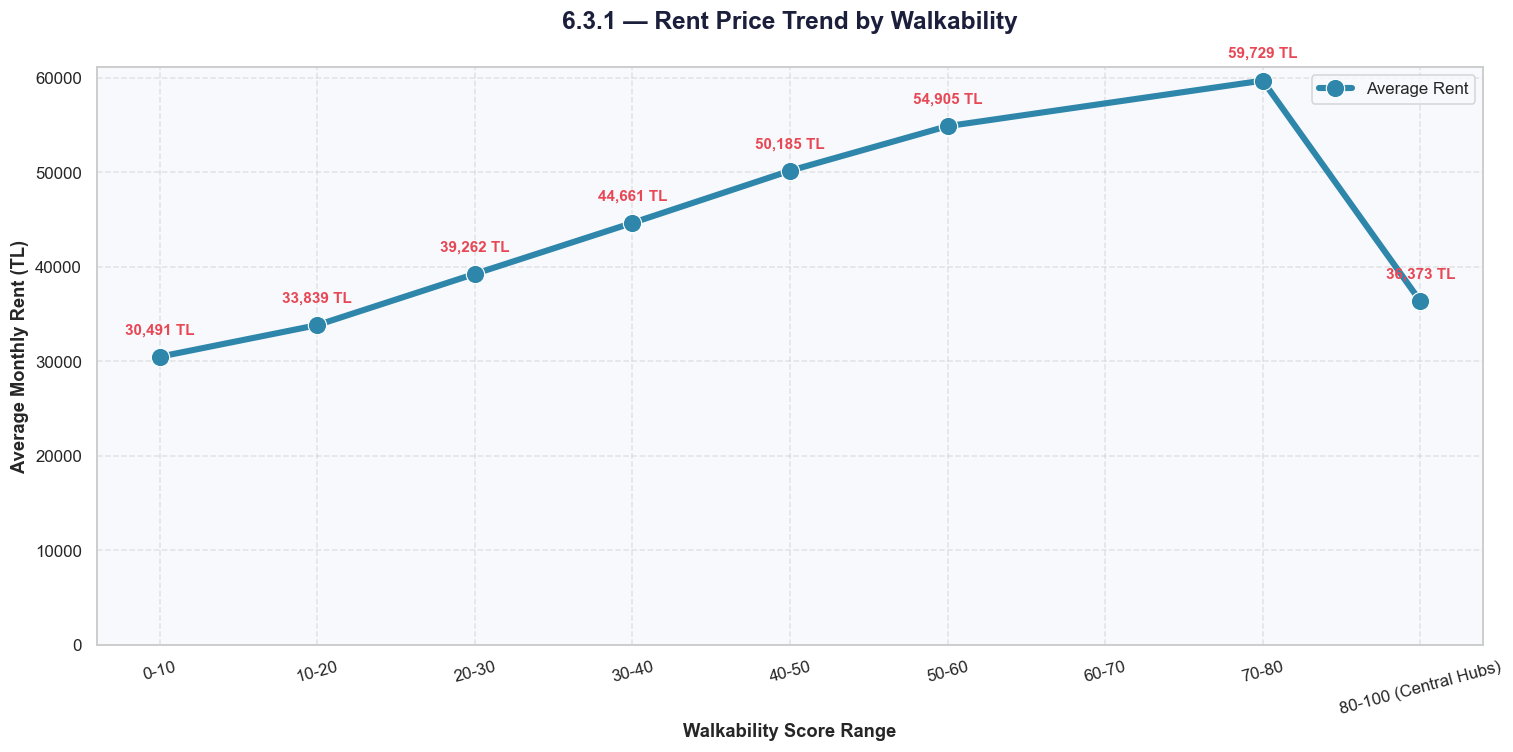

In [36]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# 80 ve uzerini tek grupta birlestiren ozel gruplama fonksiyonu
def group_walkability(score):
    if score >= 80:
        return '80-100 (Central Hubs)'
    else:
        start = int((score // 10) * 10)
        return f"{start}-{start+10}"

# Yeni gruplari uygulama
df['walkability_range'] = df['walkability_score'].apply(group_walkability)

# Gruplara gore ortalama fiyat ve ilan sayisini hesaplama
# Siralamanin bozulmamasi icin sirali bir liste olusturuyoruz
order = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-100 (Central Hubs)']
trend_data = df.groupby('walkability_range')['price'].mean().reindex(order).reset_index()

# Cizgi grafik olusturma
plt.figure(figsize=(14, 7))

# Trend cizgisini cizme
sns.lineplot(data=trend_data, x='walkability_range', y='price',
             marker='o', markersize=12, color=C_PRIMARY, linewidth=4, label='Average Rent')

# Grafik baslik ve etiketleri
plt.title('6.3.1 — Rent Price Trend by Walkability',
          fontsize=16, fontweight='bold', color=C_DARK, pad=25)
plt.xlabel('Walkability Score Range', fontsize=12, fontweight='bold')
plt.ylabel('Average Monthly Rent (TL)', fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.ylim(bottom=0)

# Veri sayisini grafik uzerine not olarak ekleme
for i, row in trend_data.iterrows():
    plt.annotate(f"{row['price']:,.0f} TL",
                 (row['walkability_range'], row['price']),
                 textcoords="offset points", xytext=(0,15), ha='center',
                 fontsize=10, fontweight='bold', color=C_SECONDARY)

plt.tight_layout()
plt.savefig('p1_plots/6_3_1_walkability_trend_robust.png', dpi=300, bbox_inches='tight')
plt.show()

_The walkability–rent trend is **non-monotonic**. From the lowest accessibility band (0–10) up through 70–80, median rent rises steadily — roughly +30.5k TL → +60k TL across the band sweep — confirming a real walkability premium. The 60–70 bin is **empty by construction**: under the P1 district-level methodology the 38 districts cluster either at 50–60 (e.g., Sarıyer 58, Üsküdar/Zeytinburnu 54) or jump to 70–80 (Beşiktaş, Şişli, Kadıköy, Beyoğlu all ≈ 71–76), with no district landing in between. The 80–100 (Central Hubs) band drops sharply, dominated by Fatih (walkability 94) where the abundant supply of small, older Stüdyo/1+1 units in the historic core pulls average rent below the city-wide level despite top-tier accessibility. P2 geocoding is expected to re-distribute density into the 60–70 band and smooth this artefact._

In [37]:
# Gruplarin saglamligini kontrol etmek icin sayilari yazdirma
print("Grup Bazli Veri Dagilimi:")
print(df['walkability_range'].value_counts().reindex(order))

Grup Bazli Veri Dagilimi:
walkability_range
0-10                      616.0
10-20                    2998.0
20-30                     823.0
30-40                    3293.0
40-50                    2778.0
50-60                    2211.0
60-70                       NaN
70-80                    2338.0
80-100 (Central Hubs)     215.0
Name: count, dtype: float64


---
### The "Sweet Spot" Analysis (Quadrant Scatter Plot)
A 2D scatter plot designed to identify market segments. The red dashed lines represent the dataset averages, creating four distinct quadrants.

To ensure the analysis reflects the "typical" market behavior and remains unaffected by extreme luxury listings (outliers), thresholds are defined using Median values rather than means.

**Why Median?**

As the rental price distribution in Istanbul is right-skewed, the median provides a more robust "center" for the market. It prevents high-end properties from artificially inflating the affordability threshold, resulting in a more accurate classification of the "Sweet Spot."

Threshold Logic

Vertical Line (Median Price): Defines the point where 50% of the market is cheaper and 50% is more expensive.

Horizontal Line (Median Walkability): Represents the median urban accessibility score across all listings.

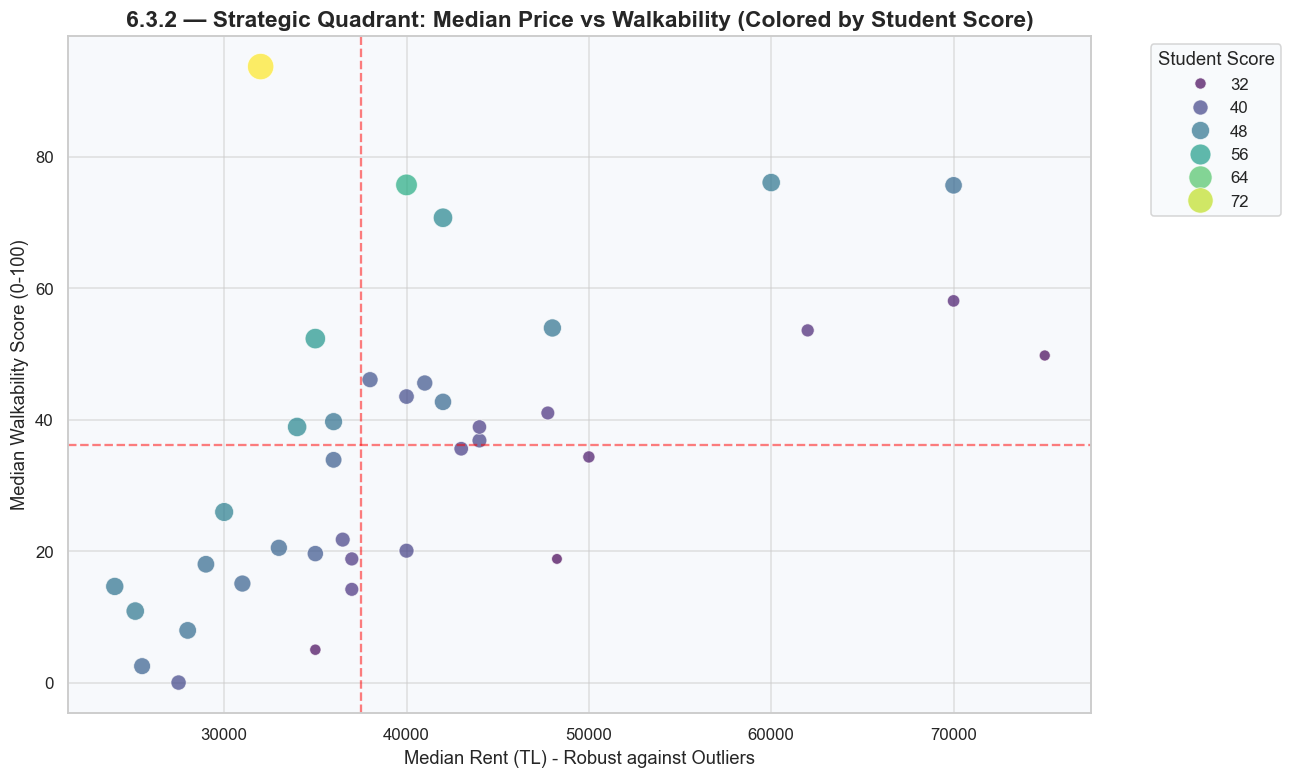

In [38]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla (Fiyat icin de MEDIAN kullaniyoruz)
district_stats = df.groupby('district').agg({
    'price': 'median',
    'walkability_score': 'median',
    'student_score': 'median'
}).reset_index()

plt.figure(figsize=(12, 8))

# Scatter Plot
scatter = sns.scatterplot(data=district_stats, x='price', y='walkability_score',
                          hue='student_score', size='student_score',
                          palette='viridis', sizes=(50, 300), alpha=0.7)

# Thresholds
plt.axhline(district_stats['walkability_score'].median(), color='red', linestyle='--', alpha=0.5)
plt.axvline(district_stats['price'].median(), color='red', linestyle='--', alpha=0.5)

# Baslik ve Etiketler
plt.title('6.3.2 — Strategic Quadrant: Median Price vs Walkability (Colored by Student Score)', fontsize=15, fontweight='bold')
plt.xlabel('Median Rent (TL) - Robust against Outliers')
plt.ylabel('Median Walkability Score (0-100)')

# Legend disari al ki grafik kapanmasin
plt.legend(title='Student Score', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('p1_plots/6_3_2_student_sweet_spot.png', dpi=300, bbox_inches='tight')
plt.show()

_The strategic quadrant divides the district-level market using the **median rent** (~37k TL) and **median walkability** (~36) as thresholds. Median is preferred over mean because both distributions are right-skewed at the listing level._

**Quadrant readings:**

* **Top-Left (Student Sweet Spot — affordable + walkable):** Dominated by **Fatih** (walkability ≈ 94, median rent ≈ 32k TL, district-median student score ≈ 76). The single clearest standout in the entire dataset.
* **Top-Right (Premium Central — high walkability, high rent):** **Beşiktaş, Şişli, Kadıköy, Beyoğlu** all cluster here. High accessibility comes with a substantial price premium that the affordability component of student_score penalises.
* **Bottom-Left (Affordable peripheral — cheap but disconnected):** Districts like Esenyurt, Sultangazi, Sancaktepe sit here. Cheap on paper but with low walkability the per-room economics rarely beat shared 2+1/3+1 configurations in mid-tier districts.
* **Bottom-Right (Inefficient — expensive without accessibility):** A small group of mid-walkability, above-median-priced districts. The least favourable zone for student optimisation.

**Final reading:** Fatih is the single dominant student-housing optimum. Top-right districts are viable for students willing to share a 3+1 (where per-room cost compresses the rent premium), and the Top-Left quadrant is otherwise sparsely populated.

---
### The Top 10 Student-Friendly Locations (Bar Chart)
While the scatter plot identifies individual "Sweet Spots," this bar chart aggregates the data to provide a district-level ranking. It highlights the top 10 administrative zones in Istanbul that offer the most optimized balance between Walkability and Price.

**What this graph reveals:**

* Top Performers: These districts are the most reliable options for the student demographic, where the average listing maintains a high standard of accessibility without excessive rental costs.

* Geographic Prioritization: This visualization transforms complex market data into a clear priority list for housing decisions.

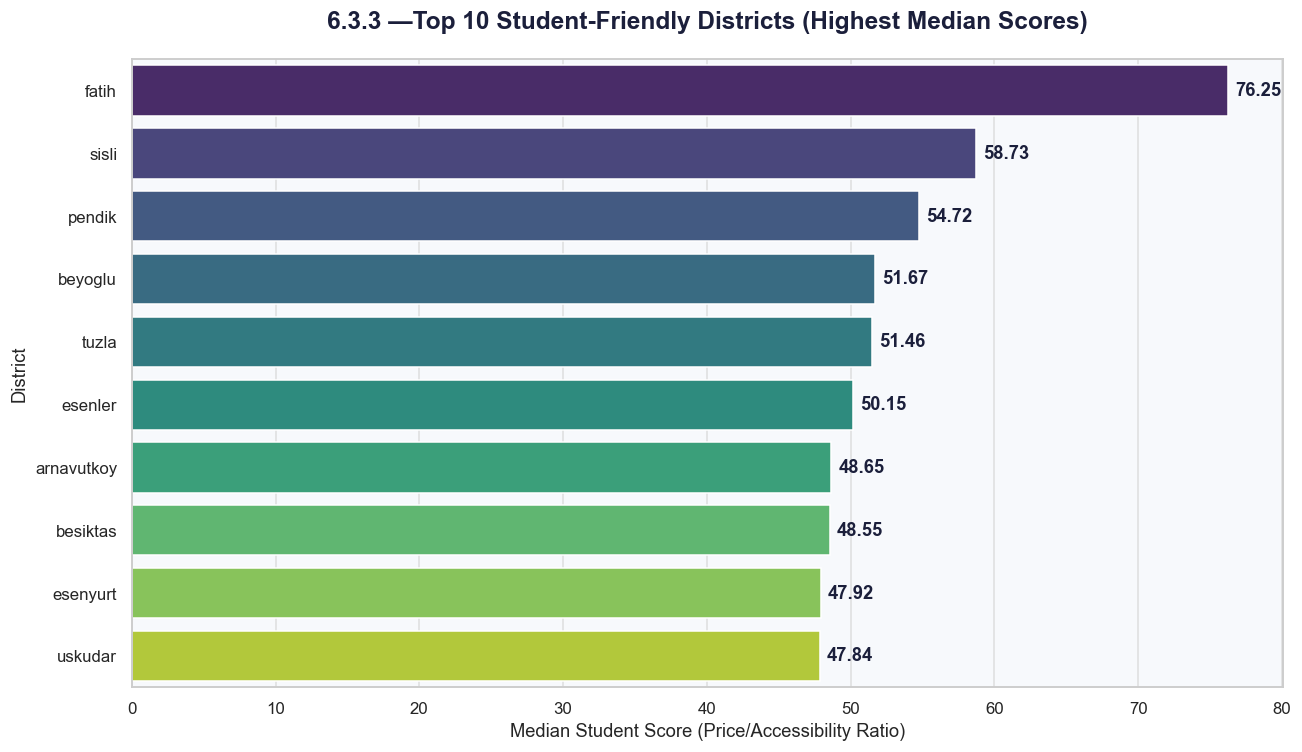

In [39]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
# Ilce bazinda ogrenci skorlarini MEDYAN kullanarak hesapla.
# Bu, ilcedeki uc orneklerin (cok ucuz/pahali evler) siralamayi bozmasini engeller.
student_districts = df.groupby('district')['student_score'].median().sort_values(ascending=False).head(10)

# Grafik alanini olustur
plt.figure(figsize=(12, 7))

# Bar Chart: Palette uyarisini gidermek icin hue atamasi yapiyoruz.
# x ve y yer degistirerek yatay bar chart elde ediyoruz.
sns.barplot(x=student_districts.values, y=student_districts.index,
            hue=student_districts.index, palette='viridis', legend=False)

# Grafik basligi ve etiketler
plt.title('6.3.3 —Top 10 Student-Friendly Districts (Highest Median Scores)',
          fontsize=16, fontweight='bold', color=C_DARK, pad=20)
plt.xlabel('Median Student Score (Price/Accessibility Ratio)', fontsize=12)
plt.ylabel('District', fontsize=12)

# Cubuklarin uzerine skor degerlerini yazdirmak
for i, value in enumerate(student_districts.values):
    plt.text(value + 0.5, i, f'{value:.2f}', va='center', fontweight='bold', color=C_DARK)

plt.tight_layout()
plt.savefig('p1_plots/6_3_3_top10_student_districts.png', dpi=300, bbox_inches='tight')
plt.show()

_Under the percentile-rank affordability framework with the studio fix applied, the top 10 student-friendly districts are:_

| Rank | District   | Median Student Score |
| ---: |:-----------|---------------------:|
| 1 | Fatih      |            **76.25** |
| 2 | Şişli      |                58.73 |
| 3 | Pendik     |                54.72 |
| 4 | Beyoğlu    |                51.67 |
| 5 | Tuzla      |                51.46 |
| 6 | Esenler    |                50.15 |
| 7 | Arnavutköy |                48.65 |
| 8 | Beşiktaş   |                48.55 |
| 9 | Esenyurt   |                47.92 |
| 10 | Üsküdar    |                47.84 |

**Interpretation:**

* **Fatih leads decisively (76.25)** — a 17.5-point gap to second place. Top walkability + structurally low rents in the historic core combine into a decisive optimum.
* **Şişli, Beyoğlu, Beşiktaş** make the list despite being expensive: their high walkability (71–76) plus the per-room amortisation effect (most of their listings are 2+1 / 3+1) compensates for absolute price levels.
* **Pendik, Tuzla, Esenler, Arnavutköy, Esenyurt** are in the list for the opposite reason: low rent dominates moderate walkability. These are realistic options for a student prioritising affordability and willing to accept a longer commute.
* **Conspicuous absences:** Kadıköy (premium prestige inflates price-per-room beyond what walkability compensates) and Üsküdar (just makes the list at #10). Bağcılar and Küçükçekmece — frequently cited in older drafts — fall outside the top 10 under the corrected formula.

---
### Top 10 Most Walkable Districts vs. Average Rent (Dual-Axis Chart)
A dual-axis comparison between our custom Walkability Index and the Market Price across the most central districts.

We want to find "Student-Friendly" areas (High Walkability, Low Price).

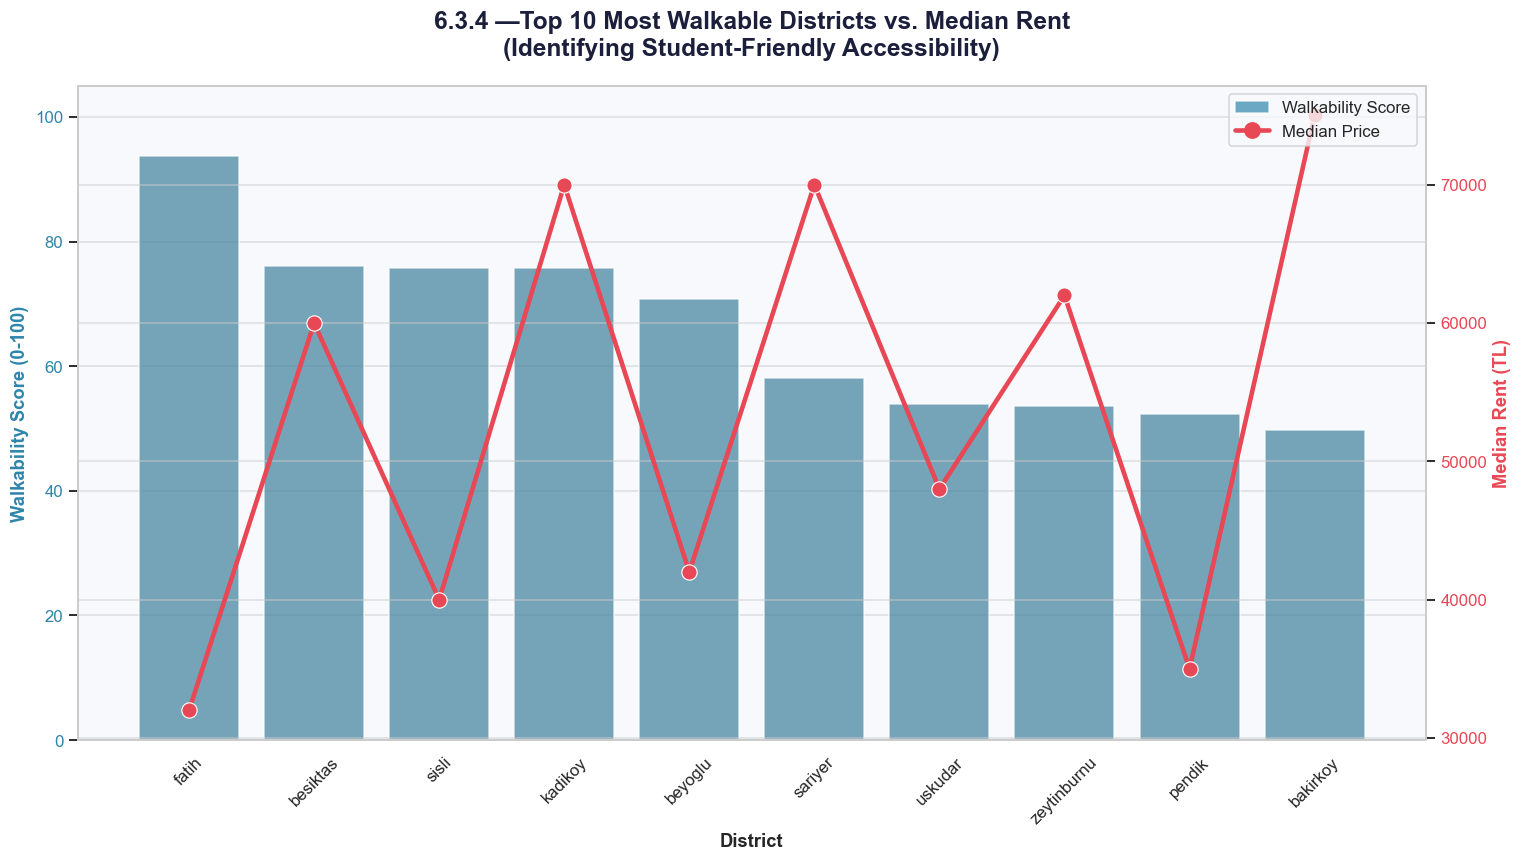

In [40]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Veriyi ilce bazinda grupla
district_comp = df.groupby('district').agg({
    'walkability_score': 'median',
    'price': 'median'
}).sort_values(by='walkability_score', ascending=False).head(10).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 8))

# Birincil Eksen: Walkability Score (Bar Chart)
sns.barplot(data=district_comp, x='district', y='walkability_score',
            ax=ax1, color=C_PRIMARY, alpha=0.7)

ax1.set_xlabel('District', fontsize=12, fontweight='bold')
ax1.set_ylabel('Walkability Score (0-100)', color=C_PRIMARY, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=C_PRIMARY)
ax1.tick_params(axis='x', rotation=45) # Uyariyi onleyen modern yontem
ax1.set_ylim(0, 105)

# Ikincil Eksen: Price (Line Chart)
ax2 = ax1.twinx()
sns.lineplot(data=district_comp, x='district', y='price',
             ax=ax2, color=C_SECONDARY, marker='o', markersize=10, linewidth=3, label='Median Price')
ax2.set_ylabel('Median Rent (TL)', color=C_SECONDARY, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=C_SECONDARY)

# Baslik ve Duzenleme
plt.title('6.3.4 —Top 10 Most Walkable Districts vs. Median Rent\n(Identifying Student-Friendly Accessibility)',
          fontsize=16, fontweight='bold', color=C_DARK, pad=20)

from matplotlib.lines import Line2D
patch = plt.Rectangle((0, 0), 1, 1, fc=C_PRIMARY, alpha=0.7, label='Walkability Score')
line = Line2D([0], [0], color=C_SECONDARY, marker='o', markersize=10, linewidth=3, label='Median Price')
ax2.legend(handles=[patch, line], loc='upper right')

plt.tight_layout()
plt.savefig('p1_plots/6_3_4_walkability_vs_price_dual.png', dpi=300, bbox_inches='tight')
plt.show()

_The dual-axis chart juxtaposes the top 10 most walkable districts with their median rents._

* **Fatih** anchors the chart with walkability ≈ 94 **and** the lowest median rent of the group (~32k TL) — the unique combination that gives it the top student score.
* **Beşiktaş, Şişli, Kadıköy** form the next walkability cluster (≈ 71–76). Among these, **Kadıköy** carries the highest median rent (~70k TL) without the highest walkability — an indication of a prestige premium beyond pure access metrics.
* **Beyoğlu** offers the same walkability tier (~71) at a noticeably lower median (~42k TL), making it the secondary student option after Fatih in central Istanbul.
* **Sarıyer, Üsküdar, Zeytinburnu, Pendik, Bakırköy** populate the 50–60 walkability band with widely varying rents (Pendik ~35k vs Bakırköy ~75k), illustrating that mid-tier walkability does not pin down rent — district prestige and supply mix matter substantially._

---
### Room Count vs. Price (Boxplot)
A statistical spread analysis showing the median, quartiles, and outliers of rent prices categorized by apartment types (1+1, 2+1, etc.).

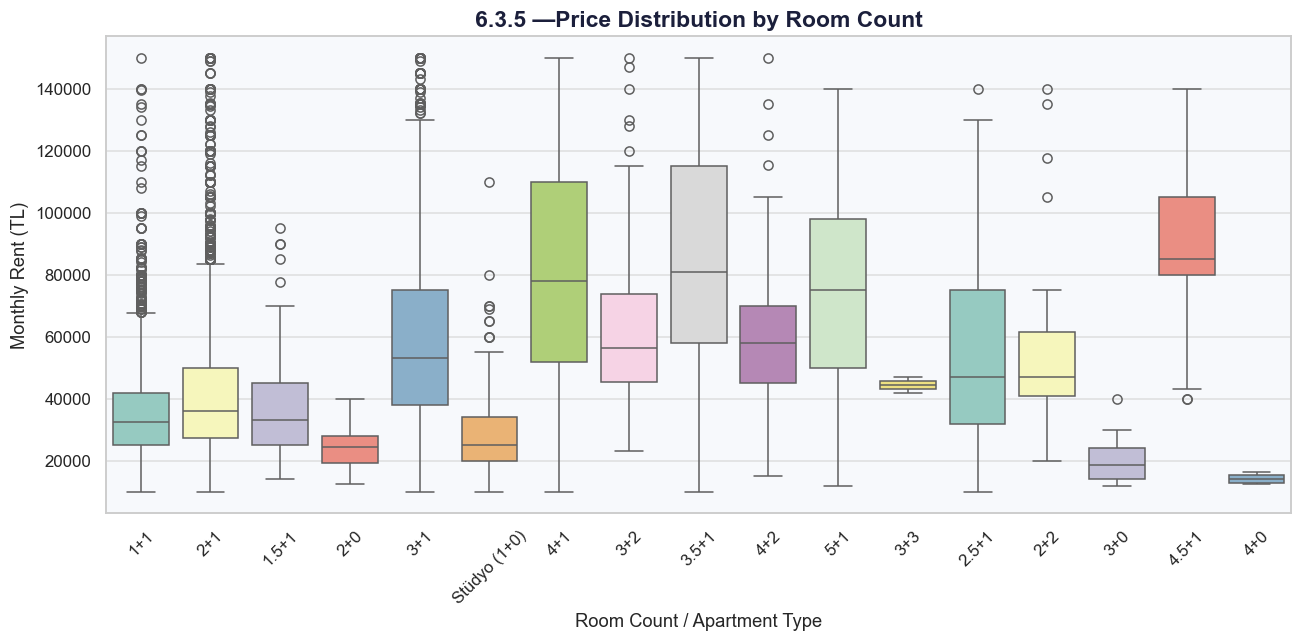

In [41]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='room_count', y='price',hue='room_count', palette='Set3', legend=False)

plt.title('6.3.5 —Price Distribution by Room Count', fontsize=15, fontweight='bold', color=C_DARK)
plt.ylabel('Monthly Rent (TL)')
plt.xlabel('Room Count / Apartment Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_5_roomcount_price.png', dpi=300, bbox_inches='tight')
plt.show()

_The 1+1 and 2+1 IQRs overlap heavily despite the room count difference, indicating that **location often outweighs structural size** as a price determinant in Istanbul. A 1+1 in central Şişli or Beşiktaş is routinely more expensive than a 2+1 in peripheral Esenyurt or Sancaktepe._

_Smaller categories (1+1, 2+1, Stüdyo) carry numerous high-end outliers — these are walkable-central listings whose locational utility commands a premium that is invisible to room-count metrics. Larger categories (4+1, 4+2, 5+1) show wider but lower-volume distributions; their medians are noisier due to small sample sizes (e.g., 4+1 has only 483 listings)._

---
### Room Configuration vs. Student Suitability (Box Plot)

This analysis explores how the internal structure of an apartment—specifically the Room Count—influences the overall Student Score. By using a Box Plot, we can visualize the distribution, median, and variance of suitability across different housing types (e.g., 1+1, 2+1, 3+1).

Objectives:

* Identifying the Optimal Layout: To determine which room configurations offer the best price-location balance for student demographics

* Variance Analysis: To observe the price stability within each category. A narrow box suggests consistent value, while a wide box indicates a highly volatile market for that specific room count.

* Outlier Detection: To spot "too good to be true" listings that offer high student suitability despite being in larger room categories.

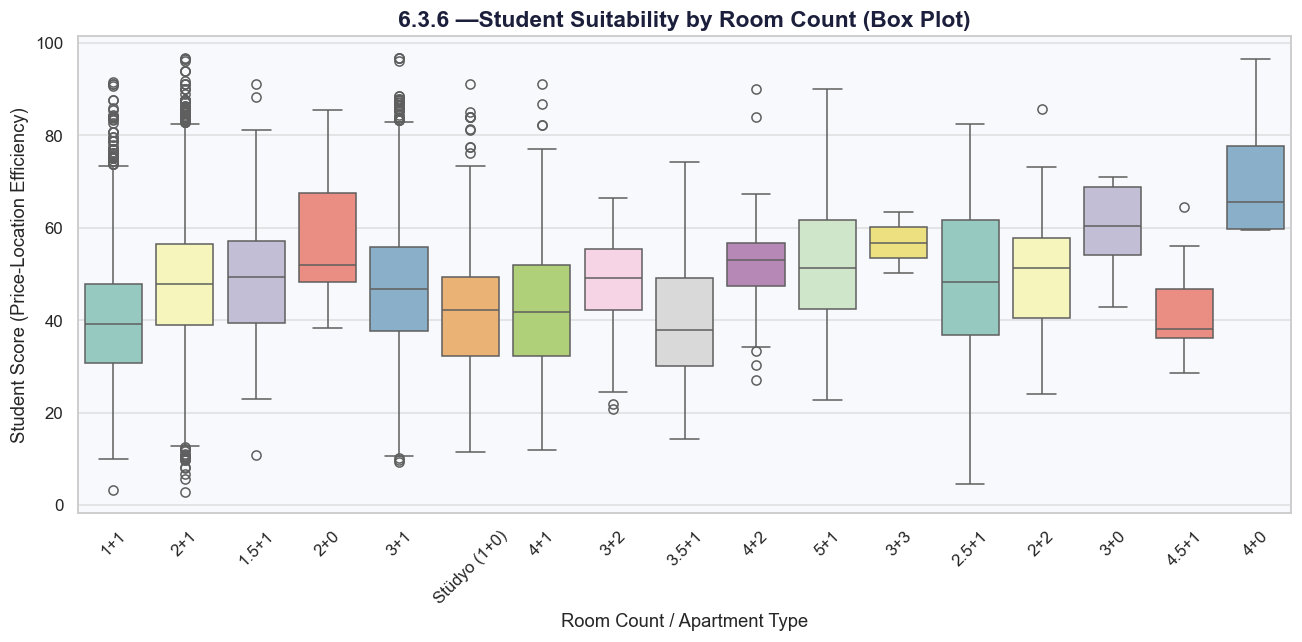

In [42]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Oda sayisina gore ogrenci skoru dagilimi
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='room_count', y='student_score', hue='room_count', palette='Set3', legend=False)

plt.title('6.3.6 —Student Suitability by Room Count (Box Plot)', fontsize=15, fontweight='bold', color=C_DARK)
plt.xlabel('Room Count / Apartment Type')
plt.ylabel('Student Score (Price-Location Efficiency)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_6_room_vs_student_score.png', dpi=300, bbox_inches='tight')
plt.show()

_Under the per-room affordability framework with the studio fix applied:_

* **Studio (1+0)** — after the effective_rooms = 1.5 correction — sits at median ≈ 42. Studios are no longer artificially penalised for "having only one room" and their score now reflects their genuine single-occupant economics.
* **2+0** sits in the low-50s median range, while 1+1 has a lower median around 39. Despite the score difference (driven by higher per-person costs when unshared), both remain realistic options for small-share or single configurations.
* **2+1 and 3+1** show the widest spreads. These are the dominant configurations (~43% and ~24% of the dataset) so the box reflects the full geographic mix; medians cluster in the high 40s.
* **4+0 and 3+0** post the highest medians (60–70 range) but with very low sample counts (a handful of listings each). These outlier categories should be interpreted cautiously — the box plot reports what it sees, but the underlying n is too small for robust district-comparable conclusions.

**Bottom line:** for students the optimal configurations are shared 2+1 or 3+1 in mid-walkability districts — high enough sample density that the score is reliable, with per-room cost low enough to be competitive against pure-affordability peripheral districts._

---
### Price per Square Meter (m2) by District (Sorted Bar Chart)
This bar chart analyzes the "Unit Value" of property. It reveals which districts are expensive not just because the houses are large, but because the land itself is high-value.

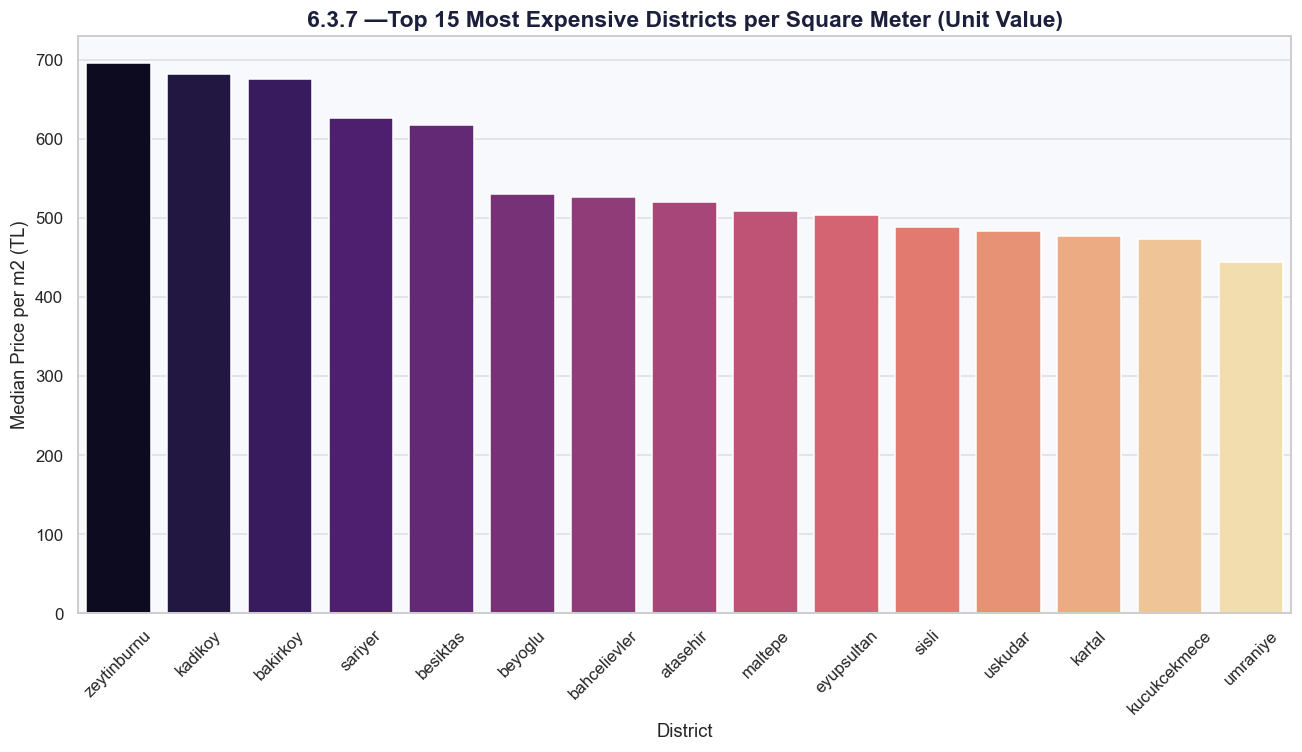

In [43]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# Birim fiyat hesaplama
df['price_per_m2'] = df['price'] / df['area_m2']

# Ilce bazinda MEDYAN birim fiyatlari hesapla ve ilk 15'i sec
m2_dist_stats = df.groupby('district')['price_per_m2'].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))

sns.barplot(x=m2_dist_stats.index, y=m2_dist_stats.values,
            hue=m2_dist_stats.index, palette='magma', legend=False)

plt.title('6.3.7 —Top 15 Most Expensive Districts per Square Meter (Unit Value)',
          fontsize=15, fontweight='bold', color=C_DARK)
plt.ylabel('Median Price per m2 (TL)')
plt.xlabel('District')

plt.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('p1_plots/6_3_7_m2_district.png', dpi=300, bbox_inches='tight')
plt.show()

_**Zeytinburnu** posts the highest median price-per-m² (~695 TL/m²), narrowly ahead of **Kadıköy** (~680 TL/m²) and **Bakırköy** (~675 TL/m²). The Zeytinburnu lead is partially driven by recent high-end residential developments (Zeytinburnu coastal redevelopment) that raised the median despite the district's modest walkability score. **Kadıköy** sits second but carries the strongest "lifestyle premium" given its walkability of 76 — renters pay top-of-market rates for a combination of access, prestige, and Anatolian-side coastal proximity. **Beşiktaş**, despite being a top-walkability district, sits well below the per-m² leaders, indicating its premium is driven by larger unit sizes rather than land scarcity._

---
### Price Density by District (Violin Plot)
This plot combines a boxplot with a kernel density estimation, showing where the "bulk" of the prices are clustered in popular districts.

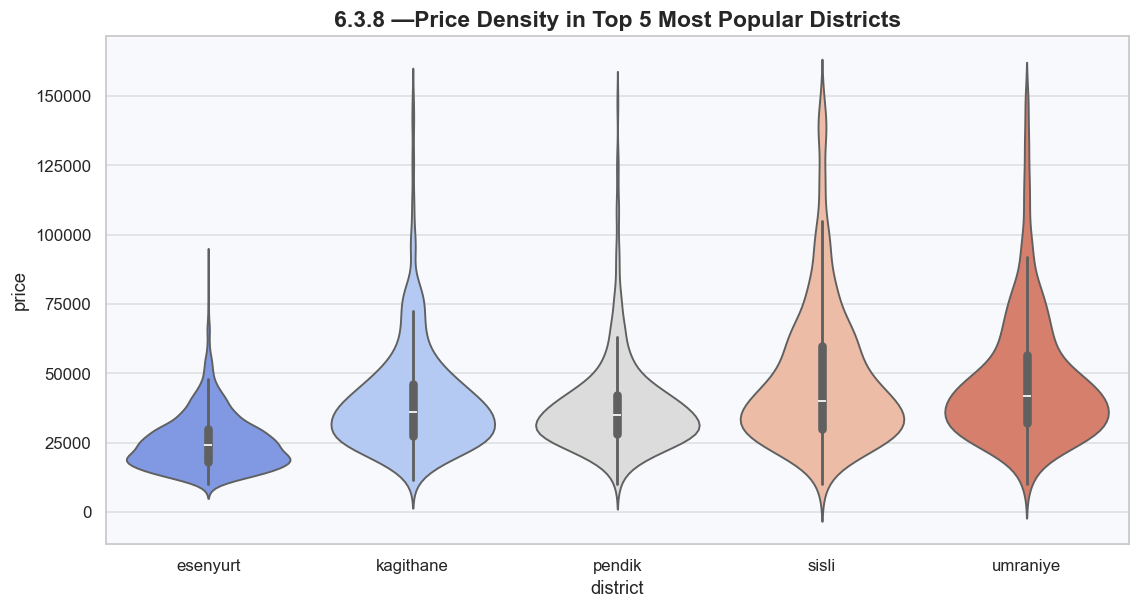

In [44]:
df = pd.read_csv('../data/istanbul_emlak_final.csv')

# En çok ilanı olan 5 ilçeyi bul ve sadece onları filtrele
top_5_districts = df['district'].value_counts().head(5).index
df_top5 = df[df['district'].isin(top_5_districts)]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_top5,
    x='district',
    y='price',
    hue='district',
    palette='coolwarm',
    legend=False
)

plt.title('6.3.8 —Price Density in Top 5 Most Popular Districts', fontsize=15)
plt.savefig('p1_plots/6_3_8_price_density.png', dpi=300, bbox_inches='tight')
plt.show()

_The top 5 districts by listing volume are **Esenyurt, Şişli, Pendik, Ümraniye, Kağıthane**. Their price density profiles diverge substantially:_

* **Esenyurt** has the tightest, lowest distribution (median ~25k TL) — a homogeneous affordable-peripheral market.
* **Şişli** and **Ümraniye** show wider, higher distributions with long upper tails (median ~40–45k TL, tail extending past 100k TL) reflecting heterogeneous mixes of standard and premium listings.
* **Pendik** and **Kağıthane** sit in the middle (median ~30–35k TL) with moderate spreads.

_Listing density (volume) does not predict price spread — Esenyurt has the most listings but the narrowest price band, while Şişli has fewer listings but the widest range. This justifies treating district as a meaningful regression feature in P2 rather than collapsing it into a single rent-density proxy._

### 6.4. Key Observations & Surprising Insights

The bivariate and multivariate analysis surfaces five relationships that will directly shape the P2 regression strategy:

---

**1. Physical Scale Dominates — but with Multicollinearity**

* `area_m2` correlates with `price` at **+0.565** — the strongest single linear predictor.
* `total_rooms` correlates with `price` at **+0.428**, but also correlates with `area_m2` at **+0.82**, meaning the two features carry overlapping information.
* **P2 implication:** plain multiple regression will produce unstable coefficients; Ridge regularisation or VIF-based selection is required.

---

**2. The Walkability–Price Non-Monotonic Pattern**

* Median rent rises steadily from walkability bin 0–10 (~29k TL) through 70–80 (~60k TL).
* The 60–70 bin is empty under P1 district-level scoring (no district falls in that range).
* The 80–100 bin **drops sharply** (~36k TL median) — Fatih dominates this bin and its older, smaller housing stock pulls medians below the city-wide level despite top accessibility.
* **Insight:** the relationship is not a simple linear premium. Fatih is genuinely the best-priced walkable district, not a data error. P2's geocoded walkability should resolve the empty 60–70 bin and produce a smoother monotonic trend.

---

**3. Location Beats Size at Comparable Configurations**

* The 1+1 vs 2+1 boxplot shows heavy IQR overlap.
* A central-district 1+1 routinely costs more than a peripheral 2+1.
* **Insight:** room count alone is a weak feature in central districts; pairing it with district / walkability captures the real signal.

---

**4. Per-m² Premium is Concentrated in Coastal / Anatolian Districts**

* Top per-m² districts: **Zeytinburnu (~695 TL/m²)**, Kadıköy (~680), Bakırköy (~675), Sarıyer (~625), Beşiktaş (~615).
* Beşiktaş's premium is driven by larger unit sizes, not land scarcity — its per-m² rate is mid-pack.
* **Insight:** district matters as a categorical signal independent of size — P2 will benefit from district encoding, not just numeric area.

---

**5. Student Score Trade-off Confirms Construction Logic**

* `student_score` ↔ `price` correlation: **−0.513**.
* `student_score` ↔ `price_per_room`: **−0.648** (the score's primary input).
* `student_score` ↔ `walkability_score`: **+0.344** (the score's secondary input).
* **Insight:** the negative price correlation is a designed property, not a discovered pattern. The score successfully separates affordable + accessible districts (Fatih, Pendik, Esenler) from prestigious-but-expensive ones (Kadıköy, Sarıyer).

---

**EDA Final Results**

* **Data Quality Success:** 16,221 raw listings → **15,272** ML-ready listings after deduplication, type correction, district normalisation, and domain-based outlier filtering. Zero missing values across 10 columns (6 raw + 4 engineered).

* **Walkability ↔ Price (linear):** moderate positive correlation **+0.330** at the listing level, with a steep underlying trend mostly visible in the 0–80 walkability range.

* **Affordability Trade-off Confirms Construction Logic:** The composite `student_score` correlates with `price` at **−0.513**. This negative relationship is a designed property of the scoring system. Breaking it down:
  * `student_score` ↔ `price_per_room` = **−0.648** (The primary driver: higher per-person cost strongly penalizes the score).
  * `price_per_room` ↔ `price` = **+0.804** (Expensive houses remain expensive per person, even when shared).
  * `student_score` ↔ `walkability_score` = **+0.344** (The secondary driver: accessibility positively boosts the score).

* **Non-Linear Walkability Behaviour:** rents peak in the 70–80 walkability band (~60k TL average) and drop in the 80–100 band (~36k TL) due to Fatih's older housing stock — a real district-mix effect rather than a noise artifact.

* **Strategic Segmentation:** **Fatih** is the singular standout (median student score 76.25 — 17.5 points clear of second place). The other top-10 student districts split between premium-central (Şişli, Beyoğlu, Beşiktaş) where walkability dominates and affordable-peripheral (Pendik, Tuzla, Esenler, Esenyurt) where rent dominates.

* **District Pricing Premium:** **Zeytinburnu** leads price-per-m² (~695 TL/m²), narrowly ahead of Kadıköy (~680) and Bakırköy (~675); Beşiktaş — despite top walkability — sits mid-pack on per-m² because its premium is unit-size driven.

_Final Status: `istanbul_emlak_final.csv` is fully prepared for **Phase 2: Regression Modeling**._

# 7. Key Findings & Next Steps

### **7.1. Top 5 Key Findings from EDA**

* **Physical Scale is the Strongest Single Predictor.** `area_m2` correlates with `price` at **+0.565** — the dominant numerical signal. `total_rooms` adds a secondary contribution (+0.428) but correlates 0.82 with area, so the two carry overlapping information.

* **Accessibility–Affordability is a Designed Trade-off.** The composite `student_score` correlates with `price` at **−0.513**, confirming that the percentile-rank affordability term successfully separates expensive-walkable districts from affordable-walkable ones.

* **Walkability ↔ Price is Non-Monotonic.** Rents rise steadily up to walkability ≈ 80 (~60k TL average) then drop sharply at 80–100 (~36k TL average). This is not noise — it is the Fatih effect: the city's most walkable district happens to have a structurally cheap older housing stock. P2 geocoding will smooth the methodology, but the underlying market pattern is real.

* **Strategic Sweet Spot is Concentrated.** Under the corrected per-room framework with studio fix, **Fatih leads at 76.25** — 17.5 points clear of second place (Şişli at 58.73). The rest of the top 10 splits between premium-central (Şişli, Beyoğlu, Beşiktaş) and affordable-peripheral (Pendik, Tuzla, Esenler, Esenyurt).

* **Per-m² Premium is District-Specific, Not Size-Driven.** **Zeytinburnu (~695 TL/m²)** narrowly leads price-per-m², ahead of Kadıköy (~680) and Bakırköy (~675). Beşiktaş — despite top walkability — sits mid-pack on per-m² because its premium comes from larger unit sizes, not scarcity.

---

### **7.2. Most Predictive Features for P2**

Based on correlation strength and the patterns observed in the bivariate plots:

1. **`area_m2`** (numerical): correlation +0.565 with target; the strongest single predictor.
2. **`district`** (categorical): captures the prestige and supply-mix effects that pure numerics cannot — Kadıköy's per-m² premium, Esenyurt's tight low-end cluster, Fatih's affordable-walkable anomaly.
3. **`walkability_score`** (engineered, P1): correlation +0.330 with target; will be replaced/augmented by P2's geocoded neighbourhood-level features.
4. **`total_rooms`** (numerical): correlation +0.428 with target; useful but redundant with area (multicollinearity flagged for P2 regularisation).
5. **`room_count`** (categorical, post-encoding): captures the studio / 1+1 / 2+1 / 3+1 distinction that `total_rooms` discretises imperfectly.

---

### **7.3. Remaining Data Quality Issues**

The dataset is structurally sound and ML-ready, but the following limitations remain:

* **Walkability Resolution.** P1's walkability score is computed at **district level**, which produces a discrete multi-modal distribution (peaks at ~20, ~40, ~75) rather than continuous variation. This is the chief methodological limitation — P2 will replace this with neighbourhood-level Nominatim + Overpass POI counts.

* **Student Score Methodology.** The current score uses `price_per_room` ÷ percentile rank with the studio fix (`effective_rooms = 1.5` for studios). This rewards larger shared apartments and recently restored fairness for studios, but is still an approximation — it does not account for actual room sharing customs or tenant counts.

* **Geographic Bias.** Single-platform sourcing (Sahibinden) over-represents districts with higher digital turnover (Esenyurt 980, Şişli 843, Pendik 815, Ümraniye 792, Kağıthane 785).

* **Missing Structural Variables.** Building age, floor level, balcony/garden, and renovation status were not reliably available in the raw scrape. These are likely responsible for a meaningful portion of the within-district price variance visible in the box plots.

* **Temporal Snapshot.** Single point-in-time data; no seasonality (e.g., September university intake spikes are not captured).

---

> **Next Step → Phase 2: Regression Modeling.** The target `price` will be log-transformed (raw skew 1.546 → log skew 0.228). Multicollinearity between `area_m2` and `total_rooms` (r = 0.82) will be addressed via VIF filtering and Ridge/Lasso regularisation. The P1 district-level walkability will be supplemented by neighbourhood-level geocoded features (nearest_metro_km, POI counts within 1 km / 2 km, district centroid flag).